In [27]:
# ====================== Time series @ configurable HEIGHT — Copernicus compliant ======================
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from datetime import datetime, timedelta

# -------- Set your target height (must be one of 20,40,...,200) --------
HEIGHT_M =  60 # <--- CHANGE THIS ONLY

# ---- Journal fonts & math (single sans-serif family; fonts embedded in PDF) ----
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 10,
})

# ---- Layout & export prefs (Copernicus) ----
FIGSIZE_2x2 = (6.85, 5.6)    # inches
FIGSIZE_1P  = (6.85, 3.2)    # single panel
DPI_PNG = 300

# ---- Data roots (as you described) ----
BASE_DIR_3DPBL = "/glade/work/mhafsah/Analysis_Proj_1/WS_all_runs"   # only 9 3dpbl runs
BASE_DIR_MAIN  = "/glade/work/mhafsah/Analysis_Proj_1/WS_d02"        # everything else

# ---- Output root (will create one folder per buoy) ----
OUT_ROOT  = "timeseries_ws"

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# ---- Colors by PBL (colorblind-safe; consistent) ----
pbl_color = {
    "ysu":   "#0072B2",  # blue
    "myj":   "#D55E00",  # vermillion
    "mynn":  "#009E73",  # bluish green
    "3dpbl": "#CC79A7",  # reddish purple
}

# 54 = densely dotted, 80 = dashdot, 93 = solid
vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}  # dense dots, dashdot, solid

# ---- Markers for ICBC (used only in 3DPBL figure) ----
icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # star, triangle, circle

# Validate and compute column index:
if HEIGHT_M % 20 != 0 or not (20 <= HEIGHT_M <= 200):
    raise ValueError(f"HEIGHT_M must be in {{20,40,...,200}}; got {HEIGHT_M}")
H_IDX = HEIGHT_M // 20 - 1  # heights are [20,40,...,200] -> indices [0..9]

# Time axis (55 samples, 10-min step)
START_TIME = datetime(2020, 5, 15, 14, 0, 0)
STEP_MIN   = 10

# ===================== YOUR ACTUAL NAMING =====================
# Directory name looks like: gfs_3dpbl_vert80 (subdir under each root)
# File name looks like: WS_E06.npy (or WS_E05.npy)
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)
ws_file_pat = re.compile(r'^WS_(?P<loc>E0[56])\.npy$')

def index_files():
    """
    Robust recursive indexing:
      - search for WS_E05.npy / WS_E06.npy anywhere under each root
      - infer (icbc, pbl, vert) from the *parent directory name* like gfs_3dpbl_vert80
      - enforce: WS_all_runs -> only 3dpbl; WS_d02 -> everything except 3dpbl
    """
    out = []

    def scan_root(root, allow_pbl=None, skip_pbl=None):
        # find WS_E05.npy and WS_E06.npy anywhere under root
        for loc in LOCATIONS:
            for f in glob.glob(os.path.join(root, "**", f"WS_{loc}.npy"), recursive=True):
                run_dir = os.path.basename(os.path.dirname(f))  # parent dir name
                m = run_dir_pat.match(run_dir)
                if not m:
                    # parent folder isn't exactly icbc_pbl_vertXX
                    continue

                g = m.groupdict()
                icbc, pbl, vert = g["icbc"], g["pbl"], g["vert"]

                if allow_pbl is not None and pbl not in allow_pbl:
                    continue
                if skip_pbl is not None and pbl in skip_pbl:
                    continue

                out.append((f, icbc, pbl, vert, loc))

    # 3DPBL-only root
    scan_root(BASE_DIR_3DPBL, allow_pbl={"3dpbl"})
    # main root (everything except 3DPBL)
    scan_root(BASE_DIR_MAIN, skip_pbl={"3dpbl"})

    return out
    
def load_ts_height(path):
    """Return time series at HEIGHT_M. Accepts (time,10) or (time,) arrays."""
    arr = np.load(path)
    if arr.ndim == 2:
        return arr[:, H_IDX]
    elif arr.ndim == 1:
        return arr
    else:
        raise ValueError(f"Unexpected array shape {arr.shape} in {path}")

def find_obs_ws(loc):
    """
    Load WS_<loc>_OBS.npy and extract HEIGHT_M column using H_IDX.
    We search:
      1) CWD
      2) either root (direct + recursive)
    """
    filename = f"WS_{loc}_OBS.npy"

    here = os.path.join(os.getcwd(), filename)
    if os.path.exists(here):
        return load_ts_height(here)

    for root in (BASE_DIR_3DPBL, BASE_DIR_MAIN):
        cand = os.path.join(root, filename)
        if os.path.exists(cand):
            return load_ts_height(cand)

        hits = glob.glob(os.path.join(root, "**", filename), recursive=True)
        if hits:
            return load_ts_height(hits[0])

    print(f"[{loc}] WS observation file not found ({filename}).")
    return None

def make_time_index(n, start_dt=START_TIME, step_min=STEP_MIN):
    return [start_dt + timedelta(minutes=i * step_min) for i in range(n)]

def panel_label(ax, txt):
    ax.text(0.02, 0.95, txt, transform=ax.transAxes, ha="left", va="top",
            fontsize=10, fontweight="bold")

def style_time_axis(ax):
    ax.set_xlabel("Time (UTC)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0, 30]))

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def plot_single_icbc_all_lines_one_panel(loc, idx, icbc_fixed):
    """
    For one buoy + one ICBC:
      - ONE panel (single axis)
      - plot ALL model lines: 4 PBLs × 3 vertical levels = 12 lines
      - color encodes PBL
      - linestyle encodes vertical levels
      - obs = black solid
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
    if not items:
        print(f"[{loc}] No matching files for {icbc_fixed}.")
        return

    # pbl -> vert -> path
    by_pbl = {p: {} for p in PBLS}
    for f, icbc, pbl, vert in items:
        by_pbl.setdefault(pbl, {})[vert] = f

    ws_obs = find_obs_ws(loc)

    # Collect all series to determine max length
    series = []  # (pbl, vert, y)
    max_n = 0
    for pbl in PBLS:
        for vert in ("54", "80", "93"):
            path = by_pbl.get(pbl, {}).get(vert)
            if path and os.path.exists(path):
                y = load_ts_height(path)
                series.append((pbl, vert, y))
                max_n = max(max_n, len(y))

    if max_n == 0:
        print(f"[{loc}] Found run dirs for {icbc_fixed} but no WS series loaded.")
        return

    t = make_time_index(max_n)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_1P, constrained_layout=True)

    # Plot all model lines
    for pbl, vert, y in series:
        ax.plot(
            t[:len(y)], y,
            color=pbl_color[pbl],
            linestyle=vert_to_ls[vert],
            linewidth=1.2,
        )

    # Obs overlay
    if ws_obs is not None:
        nobs = min(len(ws_obs), len(t))
        ax.plot(t[:nobs], ws_obs[:nobs], "-", color="black", linewidth=1.5)

    ax.set_title(f"{icbc_fixed.upper()} — {loc} @ {HEIGHT_M} m", loc="center")
    ax.set_ylabel("Wind speed (m s$^{-1}$)")
    style_time_axis(ax)

    # Make ticks less crowded
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))

    # ---- Legend: split into PBL colors + vert linestyles + obs ----
    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in PBLS
    ]
    vert_handles = [
        Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
        for v in ("54", "80", "93")
    ]
    obs_handle = [Line2D([0], [0], color="black", lw=2.0, linestyle="-", label="Obs WS")]

    handles = pbl_handles + vert_handles + obs_handle
    labels  = [h.get_label() for h in handles]

    ax.legend(
        handles, labels,
        loc="upper left",
        frameon=False,
        ncol=2,                 # compact; adjust to 3 if you prefer
        handlelength=2.4,
        columnspacing=1.2,
        labelspacing=0.5,
    )

    base = f"{icbc_fixed}_ALL12_{loc}_{HEIGHT_M}m"
    pdf_path = os.path.join(outdir, f"{base}.pdf")
    png_path = os.path.join(outdir, f"{base}.png")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {pdf_path} and {png_path}")
def plot_3dpbl_all_icbc_with_markers(loc, idx):
    """
    For one buoy:
      - single panel
      - only PBL=3dpbl (from WS_all_runs index)
      - line style = vertical levels
      - markers encode ICBC:
          era5=* (hollow), gfs=^ (hollow), hrrr=o (filled)
      - line color = 3dpbl PBL color
      - obs = black
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
    if not items:
        print(f"[{loc}] No matching files for 3DPBL.")
        return

    # icbc -> vert -> path
    by_icbc = {i: {} for i in ICBCS}
    for f, icbc, pbl, vert in items:
        by_icbc.setdefault(icbc, {})[vert] = f

    ws_obs = find_obs_ws(loc)

    # Collect series
    series = []  # (icbc, vert, y)
    max_n = 0
    for icbc in ICBCS:
        for vert in ("54", "80", "93"):
            path = by_icbc.get(icbc, {}).get(vert)
            if path and os.path.exists(path):
                y = load_ts_height(path)
                series.append((icbc, vert, y))
                max_n = max(max_n, len(y))

    if max_n == 0:
        print(f"[{loc}] 3DPBL series exist but could not be loaded.")
        return

    t = make_time_index(max_n)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_1P, constrained_layout=True)

    for icbc, vert, y in series:
        # marker face: hollow except HRRR circle filled
        mfc = "black" if (icbc == "hrrr" and icbc_marker[icbc] == "o") else "none"
        ax.plot(
            t[:len(y)], y,
            linestyle=vert_to_ls[vert],
            color=pbl_color["3dpbl"],
            linewidth=1.2,
            marker=icbc_marker[icbc],
            markevery=5,     # consistent spacing
            markersize=4.5,
            markeredgecolor="black",
            markerfacecolor=mfc,
            markeredgewidth=0.9,
        )

    if ws_obs is not None:
        nobs = min(len(ws_obs), len(t))
        ax.plot(t[:nobs], ws_obs[:nobs], "-", color="black", linewidth=1.4)

    ax.set_title(f"3DPBL — all ICBCs — {loc} @ {HEIGHT_M} m", loc="center")
    ax.set_ylabel("Wind speed (m s$^{-1}$)")
    style_time_axis(ax)

    icbc_handles = []
    for icbc in ICBCS:
        mfc = "black" if (icbc == "hrrr" and icbc_marker[icbc] == "o") else "none"
        icbc_handles.append(
            Line2D([0], [0],
                   color="black", linestyle="None",
                   marker=icbc_marker[icbc],
                   markersize=6,
                   markeredgecolor="black",
                   markerfacecolor=mfc,
                   label=icbc.upper())
        )

    vert_handles = [
        Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
        for v in ("54", "80", "93")
    ]

    obs_handle = [Line2D([0], [0], color="black", lw=2.0, linestyle="-", label="Obs WS")]

    handles = icbc_handles + vert_handles + obs_handle
    labels  = [h.get_label() for h in handles]

    ax.legend(
        handles, labels,
        loc="upper left",
        frameon=False,
        ncol=3,
        handlelength=2.2,
        columnspacing=1.2,
        labelspacing=0.5,
    )

    base = f"3dpbl_allICBC_markers_{loc}_{HEIGHT_M}m"
    pdf_path = os.path.join(outdir, f"{base}.pdf")
    png_path = os.path.join(outdir, f"{base}.png")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {pdf_path} and {png_path}")

if __name__ == "__main__":
    idx = index_files()

    for loc in LOCATIONS:
        # 1) ERA5
        plot_single_icbc_all_lines_one_panel(loc, idx, "era5")
        plot_single_icbc_all_lines_one_panel(loc, idx, "gfs")
        plot_single_icbc_all_lines_one_panel(loc, idx, "hrrr")
        # 4) 3DPBL markers plot
        plot_3dpbl_all_icbc_with_markers(loc, idx)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")


Saved: timeseries_ws/E05/era5_ALL12_E05_60m.pdf and timeseries_ws/E05/era5_ALL12_E05_60m.png
Saved: timeseries_ws/E05/gfs_ALL12_E05_60m.pdf and timeseries_ws/E05/gfs_ALL12_E05_60m.png
Saved: timeseries_ws/E05/hrrr_ALL12_E05_60m.pdf and timeseries_ws/E05/hrrr_ALL12_E05_60m.png
Saved: timeseries_ws/E05/3dpbl_allICBC_markers_E05_60m.pdf and timeseries_ws/E05/3dpbl_allICBC_markers_E05_60m.png
Saved: timeseries_ws/E06/era5_ALL12_E06_60m.pdf and timeseries_ws/E06/era5_ALL12_E06_60m.png
Saved: timeseries_ws/E06/gfs_ALL12_E06_60m.pdf and timeseries_ws/E06/gfs_ALL12_E06_60m.png
Saved: timeseries_ws/E06/hrrr_ALL12_E06_60m.pdf and timeseries_ws/E06/hrrr_ALL12_E06_60m.png
Saved: timeseries_ws/E06/3dpbl_allICBC_markers_E06_60m.pdf and timeseries_ws/E06/3dpbl_allICBC_markers_E06_60m.png
Done. Outputs in: timeseries_ws/E05 and timeseries_ws/E06


In [5]:
def debug_scan(root, n_show=30):
    print("\n=== DEBUG SCAN ROOT:", root, "===")
    subdirs = sorted([p for p in glob.glob(os.path.join(root, "*")) if os.path.isdir(p)])
    print("Immediate subdirs:", len(subdirs))
    for d in subdirs[:n_show]:
        dn = os.path.basename(d)
        m = run_dir_pat.match(dn)
        print("DIR:", dn, "  match:", bool(m))
        if m:
            for loc in LOCATIONS:
                f = os.path.join(d, f"WS_{loc}.npy")
                print("   ", os.path.basename(f), "exists:", os.path.exists(f))

idx = index_files()
print("Indexed files:", len(idx))
debug_scan(BASE_DIR_3DPBL)
debug_scan(BASE_DIR_MAIN)


Indexed files: 0

=== DEBUG SCAN ROOT: /glade/work/mhafsah/WS_all_runs ===
Immediate subdirs: 0

=== DEBUG SCAN ROOT: /glade/work/mhafsah/WS_d02 ===
Immediate subdirs: 0


In [17]:
# ====================== WD time series @ configurable HEIGHT — Copernicus compliant ======================
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from datetime import datetime, timedelta

# -------- Set your target height (must be one of 20,40,...,200) --------
HEIGHT_M = 140  # <--- CHANGE THIS ONLY

# ---- Journal fonts & math (single sans-serif family; fonts embedded in PDF) ----
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 10,
})

# ---- Layout & export prefs (Copernicus) ----
FIGSIZE_1P = (6.85, 3.2)   # single panel
DPI_PNG = 300

# ---- WD roots (as you requested) ----
BASE_DIR_3DPBL = "/glade/work/mhafsah/Analysis_Proj_1/WD_all_runs"  # 3dpbl runs live here
BASE_DIR_MAIN  = "/glade/work/mhafsah/Analysis_Proj_1/WD_d02"       # everything else lives here

# ---- Output root (separate from WS) ----
OUT_ROOT = "timeseries_wd"

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# ---- Colors by PBL (colorblind-safe; consistent) ----
pbl_color = {
    "ysu":   "#0072B2",  # blue
    "myj":   "#D55E00",  # vermillion
    "mynn":  "#009E73",  # bluish green
    "3dpbl": "#CC79A7",  # reddish purple
}

# 54 = densely dotted, 80 = dashdot, 93 = solid
vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}  # dense dots, dashdot, solid

# ---- Markers for ICBC (used only in 3DPBL figure) ----
icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # star, triangle, circle

# Validate and compute column index:
if HEIGHT_M % 20 != 0 or not (20 <= HEIGHT_M <= 200):
    raise ValueError(f"HEIGHT_M must be in {{20,40,...,200}}; got {HEIGHT_M}")
H_IDX = HEIGHT_M // 20 - 1  # heights are [20,40,...,200] -> indices [0..9]

# Time axis (55 samples, 10-min step)
START_TIME = datetime(2020, 5, 15, 14, 0, 0)
STEP_MIN   = 10

# Run directory name like: gfs_3dpbl_vert80
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

# ===================== WD specifics =====================
# File names inside each run dir are like: WD_E05.npy / WD_E06.npy
WD_PREFIX  = "WD"
OBS_SUFFIX = "_OBS"

def index_files():
    """
    Robust recursive indexing:
      - find WD_E05.npy / WD_E06.npy anywhere under each root
      - infer (icbc, pbl, vert) from the *parent directory name* like gfs_3dpbl_vert80
      - enforce:
          * WD_all_runs -> only 3dpbl
          * WD_d02      -> everything except 3dpbl
    """
    out = []

    def scan_root(root, allow_pbl=None, skip_pbl=None):
        for loc in LOCATIONS:
            for f in glob.glob(os.path.join(root, "**", f"{WD_PREFIX}_{loc}.npy"), recursive=True):
                run_dir = os.path.basename(os.path.dirname(f))
                m = run_dir_pat.match(run_dir)
                if not m:
                    continue

                g = m.groupdict()
                icbc, pbl, vert = g["icbc"], g["pbl"], g["vert"]

                if allow_pbl is not None and pbl not in allow_pbl:
                    continue
                if skip_pbl is not None and pbl in skip_pbl:
                    continue

                out.append((f, icbc, pbl, vert, loc))

    scan_root(BASE_DIR_3DPBL, allow_pbl={"3dpbl"})
    scan_root(BASE_DIR_MAIN,  skip_pbl={"3dpbl"})

    return out

def load_ts_height(path):
    """Return time series at HEIGHT_M. Accepts (time,10) or (time,) arrays."""
    arr = np.load(path)
    if arr.ndim == 2:
        return arr[:, H_IDX]
    elif arr.ndim == 1:
        return arr
    else:
        raise ValueError(f"Unexpected array shape {arr.shape} in {path}")

def find_obs_wd(loc):
    """
    Load WD_<loc>_OBS.npy and extract HEIGHT_M column using H_IDX.
    Searches:
      1) CWD
      2) BASE_DIR_MAIN (recursive)
      3) BASE_DIR_3DPBL (recursive)
    """
    filename = f"{WD_PREFIX}_{loc}{OBS_SUFFIX}.npy"  # e.g., WD_E05_OBS.npy

    here = os.path.join(os.getcwd(), filename)
    if os.path.exists(here):
        return load_ts_height(here)

    for root in (BASE_DIR_MAIN, BASE_DIR_3DPBL):
        hits = glob.glob(os.path.join(root, "**", filename), recursive=True)
        if hits:
            return load_ts_height(hits[0])

    print(f"[{loc}] WD observation file not found ({filename}).")
    return None

def make_time_index(n, start_dt=START_TIME, step_min=STEP_MIN):
    return [start_dt + timedelta(minutes=i * step_min) for i in range(n)]

def style_time_axis(ax):
    ax.set_xlabel("Time (UTC)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0, 30]))

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def plot_single_icbc_all_lines_one_panel(loc, idx, icbc_fixed):
    """
    For one buoy + one ICBC:
      - ONE panel (single axis)
      - plot ALL model lines: 4 PBLs × 3 vertical levels = 12 lines
      - color encodes PBL
      - linestyle encodes vertical levels
      - obs = black solid
      - NO 0–360 correction applied (as requested)
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
    if not items:
        print(f"[{loc}] No matching files for {icbc_fixed}.")
        return

    # pbl -> vert -> path
    by_pbl = {p: {} for p in PBLS}
    for f, icbc, pbl, vert in items:
        by_pbl.setdefault(pbl, {})[vert] = f

    wd_obs = find_obs_wd(loc)

    # Collect all series to determine max length
    series = []  # (pbl, vert, y)
    max_n = 0
    for pbl in PBLS:
        for vert in ("54", "80", "93"):
            path = by_pbl.get(pbl, {}).get(vert)
            if path and os.path.exists(path):
                y = load_ts_height(path)
                series.append((pbl, vert, y))
                max_n = max(max_n, len(y))

    if max_n == 0:
        print(f"[{loc}] Found run dirs for {icbc_fixed} but no WD series loaded.")
        return

    t = make_time_index(max_n)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_1P, constrained_layout=True)

    # Plot all model lines
    for pbl, vert, y in series:
        ax.plot(
            t[:len(y)], y,
            color=pbl_color[pbl],
            linestyle=vert_to_ls[vert],
            linewidth=1.2,
        )

    # Obs overlay
    if wd_obs is not None:
        nobs = min(len(wd_obs), len(t))
        ax.plot(t[:nobs], wd_obs[:nobs], "-", color="black", linewidth=1.5)

    ax.set_title(f"{icbc_fixed.upper()} — {loc} @ {HEIGHT_M} m", loc="center")
    ax.set_ylabel("Wind direction (°)")
    style_time_axis(ax)

    # ---- Legend: PBL colors + vert linestyles + obs ----
    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in PBLS
    ]
    vert_handles = [
        Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
        for v in ("54", "80", "93")
    ]
    obs_handle = [Line2D([0], [0], color="black", lw=2.0, linestyle="-", label="Obs WD")]

    handles = pbl_handles + vert_handles + obs_handle
    labels  = [h.get_label() for h in handles]

    ax.legend(
        handles, labels,
        loc="upper left",
        frameon=False,
        ncol=2,
        handlelength=2.4,
        columnspacing=1.2,
        labelspacing=0.5,
    )

    base = f"WD_{icbc_fixed}_ALL12_{loc}_{HEIGHT_M}m"
    pdf_path = os.path.join(outdir, f"{base}.pdf")
    png_path = os.path.join(outdir, f"{base}.png")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {pdf_path} and {png_path}")

def plot_3dpbl_all_icbc_with_markers(loc, idx):
    """
    For one buoy:
      - single panel
      - only PBL=3dpbl (from WD_all_runs index)
      - line style = vertical levels
      - markers encode ICBC:
          era5=* (hollow), gfs=^ (hollow), hrrr=o (filled)
      - line color = 3dpbl PBL color
      - obs = black
      - NO 0–360 correction applied (as requested)
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
    if not items:
        print(f"[{loc}] No matching files for 3DPBL.")
        return

    by_icbc = {i: {} for i in ICBCS}
    for f, icbc, pbl, vert in items:
        by_icbc.setdefault(icbc, {})[vert] = f

    wd_obs = find_obs_wd(loc)

    series = []
    max_n = 0
    for icbc in ICBCS:
        for vert in ("54", "80", "93"):
            path = by_icbc.get(icbc, {}).get(vert)
            if path and os.path.exists(path):
                y = load_ts_height(path)
                series.append((icbc, vert, y))
                max_n = max(max_n, len(y))

    if max_n == 0:
        print(f"[{loc}] 3DPBL series exist but could not be loaded.")
        return

    t = make_time_index(max_n)
    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_1P, constrained_layout=True)

    for icbc, vert, y in series:
        mfc = "black" if (icbc == "hrrr" and icbc_marker[icbc] == "o") else "none"
        ax.plot(
            t[:len(y)], y,
            linestyle=vert_to_ls[vert],
            color=pbl_color["3dpbl"],
            linewidth=1.2,
            marker=icbc_marker[icbc],
            markevery=5,
            markersize=4.5,
            markeredgecolor="black",
            markerfacecolor=mfc,
            markeredgewidth=0.9,
        )

    if wd_obs is not None:
        nobs = min(len(wd_obs), len(t))
        ax.plot(t[:nobs], wd_obs[:nobs], "-", color="black", linewidth=1.5)

    ax.set_title(f"3DPBL — all ICBCs — {loc} @ {HEIGHT_M} m", loc="center")
    ax.set_ylabel("Wind direction (°)")
    style_time_axis(ax)

    icbc_handles = []
    for icbc in ICBCS:
        mfc = "black" if (icbc == "hrrr" and icbc_marker[icbc] == "o") else "none"
        icbc_handles.append(
            Line2D([0], [0],
                   color="black", linestyle="None",
                   marker=icbc_marker[icbc],
                   markersize=6,
                   markeredgecolor="black",
                   markerfacecolor=mfc,
                   label=icbc.upper())
        )

    vert_handles = [
        Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
        for v in ("54", "80", "93")
    ]

    obs_handle = [Line2D([0], [0], color="black", lw=2.0, linestyle="-", label="Obs WD")]

    handles = icbc_handles + vert_handles + obs_handle
    labels  = [h.get_label() for h in handles]

    ax.legend(
        handles, labels,
        loc="upper left",
        frameon=False,
        ncol=3,
        handlelength=2.2,
        columnspacing=1.2,
        labelspacing=0.5,
    )

    base = f"WD_3dpbl_allICBC_markers_{loc}_{HEIGHT_M}m"
    pdf_path = os.path.join(outdir, f"{base}.pdf")
    png_path = os.path.join(outdir, f"{base}.png")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {pdf_path} and {png_path}")

if __name__ == "__main__":
    idx = index_files()
    print("Indexed WD files:", len(idx))
    # for row in idx[:20]:
    #     print(row)

    for loc in LOCATIONS:
        plot_single_icbc_all_lines_one_panel(loc, idx, "era5")
        plot_single_icbc_all_lines_one_panel(loc, idx, "gfs")
        plot_single_icbc_all_lines_one_panel(loc, idx, "hrrr")
        plot_3dpbl_all_icbc_with_markers(loc, idx)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")


Indexed WD files: 72
Saved: timeseries_wd/E05/WD_era5_ALL12_E05_140m.pdf and timeseries_wd/E05/WD_era5_ALL12_E05_140m.png
Saved: timeseries_wd/E05/WD_gfs_ALL12_E05_140m.pdf and timeseries_wd/E05/WD_gfs_ALL12_E05_140m.png
Saved: timeseries_wd/E05/WD_hrrr_ALL12_E05_140m.pdf and timeseries_wd/E05/WD_hrrr_ALL12_E05_140m.png
Saved: timeseries_wd/E05/WD_3dpbl_allICBC_markers_E05_140m.pdf and timeseries_wd/E05/WD_3dpbl_allICBC_markers_E05_140m.png
Saved: timeseries_wd/E06/WD_era5_ALL12_E06_140m.pdf and timeseries_wd/E06/WD_era5_ALL12_E06_140m.png
Saved: timeseries_wd/E06/WD_gfs_ALL12_E06_140m.pdf and timeseries_wd/E06/WD_gfs_ALL12_E06_140m.png
Saved: timeseries_wd/E06/WD_hrrr_ALL12_E06_140m.pdf and timeseries_wd/E06/WD_hrrr_ALL12_E06_140m.png
Saved: timeseries_wd/E06/WD_3dpbl_allICBC_markers_E06_140m.pdf and timeseries_wd/E06/WD_3dpbl_allICBC_markers_E06_140m.png
Done. Outputs in: timeseries_wd/E05 and timeseries_wd/E06


In [3]:
# ====================== TI time series @ configurable HEIGHT — Copernicus compliant ======================
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from datetime import datetime, timedelta

# -------- Set your target height (must be one of 20,40,...,200) --------
HEIGHT_M = 140  # <--- CHANGE THIS ONLY

# ---- Journal fonts & math (single sans-serif family; fonts embedded in PDF) ----
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 10,
})

# ---- Layout & export prefs (Copernicus) ----
FIGSIZE_1P = (6.85, 3.2)   # single panel
DPI_PNG = 300

# ---- TI roots (parallel to WS/WD organization) ----
BASE_DIR_3DPBL = "/glade/work/mhafsah/Analysis_Proj_1/TI_all_runs"  # 3dpbl runs live here
BASE_DIR_MAIN  = "/glade/work/mhafsah/Analysis_Proj_1/TI_d02"       # everything else lives here

# ---- Output root (separate from WS/WD) ----
OUT_ROOT = "timeseries_ti"

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# ---- Colors by PBL (colorblind-safe; consistent) ----
pbl_color = {
    "ysu":   "#0072B2",  # blue
    "myj":   "#D55E00",  # vermillion
    "mynn":  "#009E73",  # bluish green
    "3dpbl": "#CC79A7",  # reddish purple
}

# 54 = densely dotted, 80 = dashdot, 93 = solid
vert_to_label = {"54": "54 levels", "80": "80 levels", "93": "93 levels"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}  # dense dots, dashdot, solid

# ---- Markers for ICBC (used only in 3DPBL figure) ----
icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}  # star, triangle, circle

# Validate and compute column index:
if HEIGHT_M % 20 != 0 or not (20 <= HEIGHT_M <= 200):
    raise ValueError(f"HEIGHT_M must be in {{20,40,...,200}}; got {HEIGHT_M}")
H_IDX = HEIGHT_M // 20 - 1  # heights are [20,40,...,200] -> indices [0..9]

# Time axis (55 samples, 10-min step)
START_TIME = datetime(2020, 5, 15, 14, 10, 0)
STEP_MIN   = 10

# Run directory name like: gfs_3dpbl_vert80
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

# ===================== TI specifics =====================
# File names inside each run dir are like: TI_E05.npy / TI_E06.npy
TI_PREFIX  = "TI"
OBS_SUFFIX = "_OBS"

def index_files():
    """
    Robust recursive indexing:
      - find TI_E05.npy / TI_E06.npy anywhere under each root
      - infer (icbc, pbl, vert) from the *parent directory name* like gfs_3dpbl_vert80
      - enforce:
          * TI_all_runs -> only 3dpbl
          * TI_d02      -> everything except 3dpbl
    """
    out = []

    def scan_root(root, allow_pbl=None, skip_pbl=None):
        for loc in LOCATIONS:
            for f in glob.glob(os.path.join(root, "**", f"{TI_PREFIX}_{loc}.npy"), recursive=True):
                run_dir = os.path.basename(os.path.dirname(f))
                m = run_dir_pat.match(run_dir)
                if not m:
                    continue

                g = m.groupdict()
                icbc, pbl, vert = g["icbc"], g["pbl"], g["vert"]

                if allow_pbl is not None and pbl not in allow_pbl:
                    continue
                if skip_pbl is not None and pbl in skip_pbl:
                    continue

                out.append((f, icbc, pbl, vert, loc))

    scan_root(BASE_DIR_3DPBL, allow_pbl={"3dpbl"})
    scan_root(BASE_DIR_MAIN,  skip_pbl={"3dpbl"})

    return out

def load_ts_height(path):
    """Return time series at HEIGHT_M. Accepts (time,10) or (time,) arrays."""
    arr = np.load(path)
    if arr.ndim == 2:
        return arr[:, H_IDX]
    elif arr.ndim == 1:
        return arr
    else:
        raise ValueError(f"Unexpected array shape {arr.shape} in {path}")

def find_obs_ti(loc):
    """
    Load TI_<loc>_OBS.npy and extract HEIGHT_M column using H_IDX.
    Searches:
      1) CWD
      2) BASE_DIR_MAIN (recursive)
      3) BASE_DIR_3DPBL (recursive)
    """
    filename = f"{TI_PREFIX}_{loc}{OBS_SUFFIX}.npy"  # e.g., TI_E05_OBS.npy

    here = os.path.join(os.getcwd(), filename)
    if os.path.exists(here):
        return load_ts_height(here)

    for root in (BASE_DIR_MAIN, BASE_DIR_3DPBL):
        hits = glob.glob(os.path.join(root, "**", filename), recursive=True)
        if hits:
            return load_ts_height(hits[0])

    print(f"[{loc}] TI observation file not found ({filename}).")
    return None

def make_time_index(n, start_dt=START_TIME, step_min=STEP_MIN):
    return [start_dt + timedelta(minutes=i * step_min) for i in range(n)]

def style_time_axis(ax):
    ax.set_xlabel("Time (UTC)")
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0, 30]))

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def plot_single_icbc_all_lines_one_panel(loc, idx, icbc_fixed):
    """
    For one buoy + one ICBC:
      - ONE panel (single axis)
      - plot ALL model lines: 4 PBLs × 3 vertical levels = 12 lines
      - color encodes PBL
      - linestyle encodes vertical levels
      - obs = black solid
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and icbc == icbc_fixed]
    if not items:
        print(f"[{loc}] No matching files for {icbc_fixed}.")
        return

    # pbl -> vert -> path
    by_pbl = {p: {} for p in PBLS}
    for f, icbc, pbl, vert in items:
        by_pbl.setdefault(pbl, {})[vert] = f

    ti_obs = find_obs_ti(loc)

    # Collect all series to determine max length
    series = []  # (pbl, vert, y)
    max_n = 0
    for pbl in PBLS:
        for vert in ("54", "80", "93"):
            path = by_pbl.get(pbl, {}).get(vert)
            if path and os.path.exists(path):
                y = load_ts_height(path)
                series.append((pbl, vert, y))
                max_n = max(max_n, len(y))

    if max_n == 0:
        print(f"[{loc}] Found run dirs for {icbc_fixed} but no TI series loaded.")
        return

    t = make_time_index(max_n)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_1P, constrained_layout=True)

    # Plot all model lines
    for pbl, vert, y in series:
        ax.plot(
            t[:len(y)], y,
            color=pbl_color[pbl],
            linestyle=vert_to_ls[vert],
            linewidth=1.2,
        )

    # Obs overlay
    if ti_obs is not None:
        nobs = min(len(ti_obs), len(t))
        ax.plot(t[:nobs], ti_obs[:nobs], "-", color="black", linewidth=1.5)

    ax.set_title(f"{icbc_fixed.upper()} — {loc} @ {HEIGHT_M} m", loc="center")
    ax.set_ylabel("Turbulence intensity (-)")
    style_time_axis(ax)

    # ---- Legend: PBL colors + vert linestyles + obs ----
    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in PBLS
    ]
    vert_handles = [
        Line2D([0], [0], color="black", lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
        for v in ("54", "80", "93")
    ]
    obs_handle = [Line2D([0], [0], color="black", lw=2.0, linestyle="-", label="Obs TI")]

    handles = pbl_handles + vert_handles + obs_handle
    labels  = [h.get_label() for h in handles]

    ax.legend(
        handles, labels,
        loc="upper left",
        frameon=False,
        ncol=2,
        handlelength=2.4,
        columnspacing=1.2,
        labelspacing=0.5,
    )

    base = f"TI_{icbc_fixed}_ALL12_{loc}_{HEIGHT_M}m"
    pdf_path = os.path.join(outdir, f"{base}.pdf")
    png_path = os.path.join(outdir, f"{base}.png")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {pdf_path} and {png_path}")

def plot_3dpbl_all_icbc_with_markers(loc, idx):
    """
    For one buoy:
      - single panel
      - only PBL=3dpbl (from TI_all_runs index)
      - line style = vertical levels
      - markers encode ICBC:
          era5=* (hollow), gfs=^ (hollow), hrrr=o (filled)
      - line color = 3dpbl PBL color
      - obs = black
    """
    outdir = ensure_outdir(loc)

    items = [(f, icbc, pbl, vert) for (f, icbc, pbl, vert, L) in idx if L == loc and pbl == "3dpbl"]
    if not items:
        print(f"[{loc}] No matching files for 3DPBL.")
        return

    by_icbc = {i: {} for i in ICBCS}
    for f, icbc, pbl, vert in items:
        by_icbc.setdefault(icbc, {})[vert] = f

    ti_obs = find_obs_ti(loc)

    series = []
    max_n = 0
    for icbc in ICBCS:
        for vert in ("54", "80", "93"):
            path = by_icbc.get(icbc, {}).get(vert)
            if path and os.path.exists(path):
                y = load_ts_height(path)
                series.append((icbc, vert, y))
                max_n = max(max_n, len(y))

    if max_n == 0:
        print(f"[{loc}] 3DPBL series exist but could not be loaded.")
        return

    t = make_time_index(max_n)
    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_1P, constrained_layout=True)

    for icbc, vert, y in series:
        mfc = "black" if (icbc == "hrrr" and icbc_marker[icbc] == "o") else "none"
        ax.plot(
            t[:len(y)], y,
            linestyle=vert_to_ls[vert],
            color=pbl_color["3dpbl"],
            linewidth=1.2,
            marker=icbc_marker[icbc],
            markevery=5,
            markersize=4.5,
            markeredgecolor="black",
            markerfacecolor=mfc,
            markeredgewidth=0.9,
        )

    if ti_obs is not None:
        nobs = min(len(ti_obs), len(t))
        ax.plot(t[:nobs], ti_obs[:nobs], "-", color="black", linewidth=1.5)

    ax.set_title(f"3DPBL — all ICBCs — {loc} @ {HEIGHT_M} m", loc="center")
    ax.set_ylabel("Turbulence intensity (-)")
    style_time_axis(ax)

    icbc_handles = []
    for icbc in ICBCS:
        mfc = "black" if (icbc == "hrrr" and icbc_marker[icbc] == "o") else "none"
        icbc_handles.append(
            Line2D([0], [0],
                   color="black", linestyle="None",
                   marker=icbc_marker[icbc],
                   markersize=6,
                   markeredgecolor="black",
                   markerfacecolor=mfc,
                   label=icbc.upper())
        )

    vert_handles = [
        Line2D([0], [0], color=pbl_color["3dpbl"], lw=1.8, linestyle=vert_to_ls[v], label=vert_to_label[v])
        for v in ("54", "80", "93")
    ]

    obs_handle = [Line2D([0], [0], color="black", lw=2.0, linestyle="-", label="Obs TI")]

    handles = icbc_handles + vert_handles + obs_handle
    labels  = [h.get_label() for h in handles]

    ax.legend(
        handles, labels,
        loc="upper left",
        frameon=False,
        ncol=3,
        handlelength=2.2,
        columnspacing=1.2,
        labelspacing=0.5,
    )

    base = f"TI_3dpbl_allICBC_markers_{loc}_{HEIGHT_M}m"
    pdf_path = os.path.join(outdir, f"{base}.pdf")
    png_path = os.path.join(outdir, f"{base}.png")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=DPI_PNG, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {pdf_path} and {png_path}")

if __name__ == "__main__":
    idx = index_files()
    print("Indexed TI files:", len(idx))
    # for row in idx[:20]:
    #     print(row)

    for loc in LOCATIONS:
        plot_single_icbc_all_lines_one_panel(loc, idx, "era5")
        plot_single_icbc_all_lines_one_panel(loc, idx, "gfs")
        plot_single_icbc_all_lines_one_panel(loc, idx, "hrrr")
        plot_3dpbl_all_icbc_with_markers(loc, idx)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")


Indexed TI files: 54
Saved: timeseries_ti/E05/TI_era5_ALL12_E05_140m.pdf and timeseries_ti/E05/TI_era5_ALL12_E05_140m.png
Saved: timeseries_ti/E05/TI_gfs_ALL12_E05_140m.pdf and timeseries_ti/E05/TI_gfs_ALL12_E05_140m.png
Saved: timeseries_ti/E05/TI_hrrr_ALL12_E05_140m.pdf and timeseries_ti/E05/TI_hrrr_ALL12_E05_140m.png
Saved: timeseries_ti/E05/TI_3dpbl_allICBC_markers_E05_140m.pdf and timeseries_ti/E05/TI_3dpbl_allICBC_markers_E05_140m.png
Saved: timeseries_ti/E06/TI_era5_ALL12_E06_140m.pdf and timeseries_ti/E06/TI_era5_ALL12_E06_140m.png
Saved: timeseries_ti/E06/TI_gfs_ALL12_E06_140m.pdf and timeseries_ti/E06/TI_gfs_ALL12_E06_140m.png
Saved: timeseries_ti/E06/TI_hrrr_ALL12_E06_140m.pdf and timeseries_ti/E06/TI_hrrr_ALL12_E06_140m.png
Saved: timeseries_ti/E06/TI_3dpbl_allICBC_markers_E06_140m.pdf and timeseries_ti/E06/TI_3dpbl_allICBC_markers_E06_140m.png
Done. Outputs in: timeseries_ti/E05 and timeseries_ti/E06


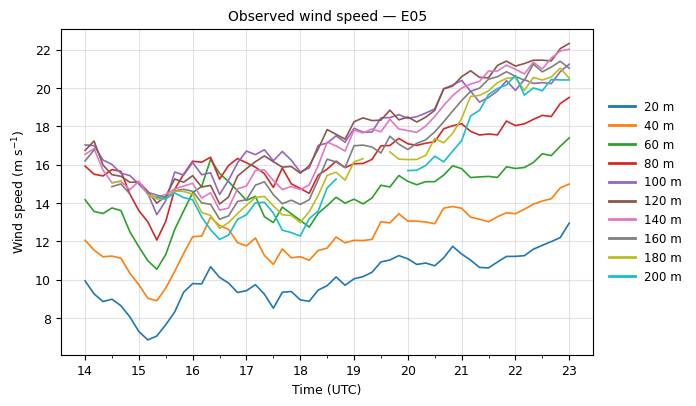

Saved: timeseries_obs_ws/obs_ws_E05_10heights.pdf and timeseries_obs_ws/obs_ws_E05_10heights.png


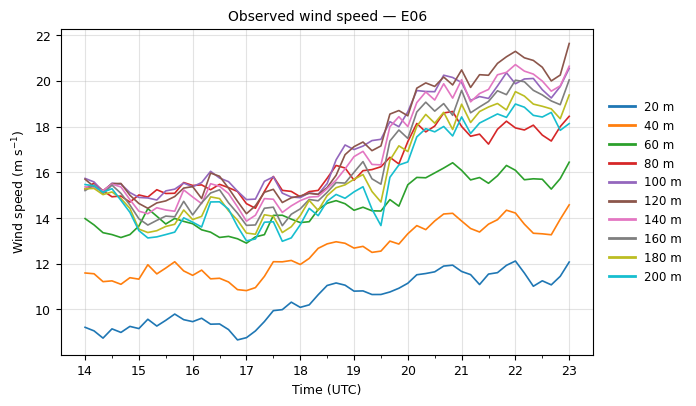

Saved: timeseries_obs_ws/obs_ws_E06_10heights.pdf and timeseries_obs_ws/obs_ws_E06_10heights.png
Done. Outputs in: timeseries_obs_ws


In [2]:
# ====================== OBS WS time series by height — Copernicus compliant ======================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from matplotlib.lines import Line2D

# ---------------- User settings ----------------
LOCATIONS = ["E05", "E06"]

# Where OBS files live (script will also check CWD)
OBS_SEARCH_DIRS = [
    os.getcwd(),
    "/glade/work/mhafsah/Analysis_Proj_1",  # optional: adjust if needed
]

# Files expected: WS_E05_OBS.npy, WS_E06_OBS.npy
# Shape expected: (time, 10) where columns correspond to heights [20..200] m
HEIGHTS_M = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# Time axis (55 samples, 10-min step)
START_TIME = datetime(2020, 5, 15, 14, 0, 0)
STEP_MIN   = 10

# Plot/export
OUT_ROOT = "timeseries_obs_ws"   # <- single folder, no subfolders
FIGSIZE  = (6.85, 3.95)
DPI_PNG  = 300

# ---- Fonts ----
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
})

# ---------------- Helpers ----------------
def make_time_index(n, start_dt=START_TIME, step_min=STEP_MIN):
    return [start_dt + timedelta(minutes=i * step_min) for i in range(n)]

def find_obs_file(loc):
    fn = f"WS_{loc}_OBS.npy"
    for d in OBS_SEARCH_DIRS:
        p = os.path.join(d, fn)
        if os.path.exists(p):
            return p
    for d in OBS_SEARCH_DIRS:
        for root, _, files in os.walk(d):
            if fn in files:
                return os.path.join(root, fn)
    return None

# ---------------- Main plotting ----------------
def plot_obs_ws_by_height(loc):
    path = find_obs_file(loc)
    if path is None:
        print(f"[{loc}] Obs file not found: WS_{loc}_OBS.npy")
        return

    arr = np.load(path)
    if arr.ndim != 2 or arr.shape[1] != 10:
        raise ValueError(f"[{loc}] Expected obs shape (time,10); got {arr.shape} from {path}")

    n = arr.shape[0]
    t = make_time_index(n)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    colors = plt.get_cmap("tab10").colors[:len(HEIGHTS_M)]

    handles = []
    for j, (h, c) in enumerate(zip(HEIGHTS_M, colors)):
        y = arr[:, j]
        ax.plot(t, y, linewidth=1.2, color=c)
        handles.append(Line2D([0], [0], color=c, lw=2.0, label=f"{int(h)} m"))

    ax.set_title(f"Observed wind speed — {loc}", loc="center")
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("Wind speed (m s$^{-1}$)")
    ax.grid(True, alpha=0.35, linewidth=0.8)

    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0, 30]))

    ax.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        ncol=1,
        handlelength=2.2,
        labelspacing=0.5,
        borderaxespad=0.0,
    )

    os.makedirs(OUT_ROOT, exist_ok=True)
    base = f"obs_ws_{loc}_10heights"
    pdf_path = os.path.join(OUT_ROOT, f"{base}.pdf")
    png_path = os.path.join(OUT_ROOT, f"{base}.png")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=DPI_PNG, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {pdf_path} and {png_path}")

if __name__ == "__main__":
    for loc in LOCATIONS:
        plot_obs_ws_by_height(loc)
    print(f"Done. Outputs in: {OUT_ROOT}")


In [ ]:
# ====================== OBS WD time series by height — Copernicus compliant ======================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from matplotlib.lines import Line2D

# ---------------- User settings ----------------
LOCATIONS = ["E05", "E06"]

# Where OBS files live (script will also check CWD)
OBS_SEARCH_DIRS = [
    os.getcwd(),
    "/glade/work/mhafsah/Analysis_Proj_1",  # optional: adjust if needed
]

# Files expected: WD_E05_OBS.npy, WD_E06_OBS.npy
# Shape expected: (time, 10) where columns correspond to heights [20..200] m
HEIGHTS_M = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# Time axis (55 samples, 10-min step)
START_TIME = datetime(2020, 5, 15, 14, 0, 0)
STEP_MIN   = 10

# Plot/export
OUT_ROOT = "timeseries_obs_wd"   # <- single folder, no subfolders
FIGSIZE  = (6.85, 3.95)
DPI_PNG  = 300

# ---- Fonts ----
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
})

# ---------------- Helpers ----------------
def make_time_index(n, start_dt=START_TIME, step_min=STEP_MIN):
    return [start_dt + timedelta(minutes=i * step_min) for i in range(n)]

def find_obs_file(loc):
    fn = f"WD_{loc}_OBS.npy"
    for d in OBS_SEARCH_DIRS:
        p = os.path.join(d, fn)
        if os.path.exists(p):
            return p
    for d in OBS_SEARCH_DIRS:
        for root, _, files in os.walk(d):
            if fn in files:
                return os.path.join(root, fn)
    return None

# ---------------- Main plotting ----------------
def plot_obs_wd_by_height(loc):
    path = find_obs_file(loc)
    if path is None:
        print(f"[{loc}] Obs file not found: WD_{loc}_OBS.npy")
        return

    arr = np.load(path)
    if arr.ndim != 2 or arr.shape[1] != 10:
        raise ValueError(f"[{loc}] Expected obs shape (time,10); got {arr.shape} from {path}")

    n = arr.shape[0]
    t = make_time_index(n)

    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, constrained_layout=True)

    colors = plt.get_cmap("tab10").colors[:len(HEIGHTS_M)]

    handles = []
    for j, (h, c) in enumerate(zip(HEIGHTS_M, colors)):
        y = arr[:, j]
        ax.plot(t, y, linewidth=1.2, color=c)
        handles.append(Line2D([0], [0], color=c, lw=2.0, label=f"{int(h)} m"))

    ax.set_title(f"Observed wind direction — {loc}", loc="center")
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("Wind direction (°)")
    ax.grid(True, alpha=0.35, linewidth=0.8)

    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0, 30]))

    ax.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        ncol=1,
        handlelength=2.2,
        labelspacing=0.5,
        borderaxespad=0.0,
    )

    os.makedirs(OUT_ROOT, exist_ok=True)
    base = f"obs_wd_{loc}_10heights"
    pdf_path = os.path.join(OUT_ROOT, f"{base}.pdf")
    png_path = os.path.join(OUT_ROOT, f"{base}.png")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=DPI_PNG, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {pdf_path} and {png_path}")

if __name__ == "__main__":
    for loc in LOCATIONS:
        plot_obs_wd_by_height(loc)
    print(f"Done. Outputs in: {OUT_ROOT}")


Using y-limits for 200 m: (6.5, 24.0)


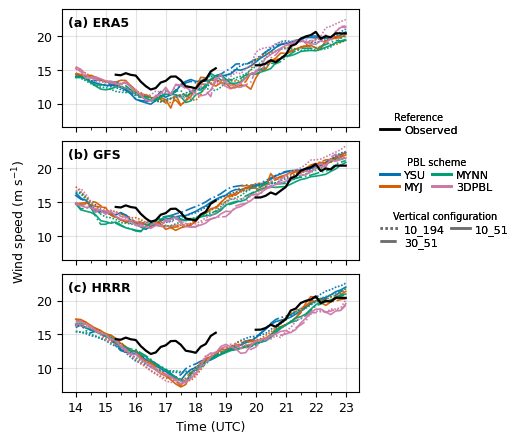

Saved: timeseries_ws_3panel/E05/ws_timeseries_3panel_E05_200m.pdf
Saved: timeseries_ws_3panel/E05/ws_timeseries_3panel_E05_200m.png


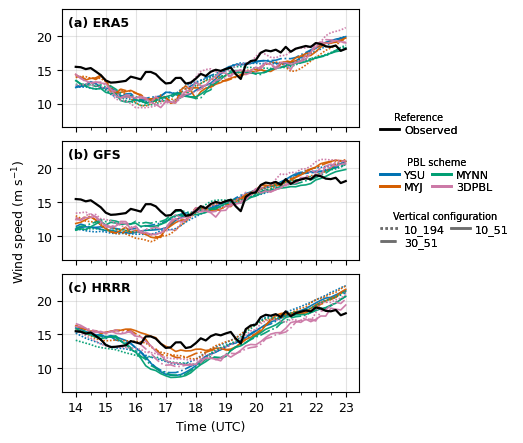

Saved: timeseries_ws_3panel/E06/ws_timeseries_3panel_E06_200m.pdf
Saved: timeseries_ws_3panel/E06/ws_timeseries_3panel_E06_200m.png
Done. Outputs in: timeseries_ws_3panel/E05 and timeseries_ws_3panel/E06


In [53]:
# ====================== Individual WS time series @ selected HEIGHT — 3 panels ======================
# Panel (a): ERA5
# Panel (b): GFS
# Panel (c): HRRR
#
# Each panel contains all:
#   PBL schemes × vertical configurations
#
# Encoding:
#   color     = PBL scheme
#   linestyle = vertical configuration
#   black     = lidar observation
#
# NOTE:
#   3DPBL is NOT a separate panel anymore.
#   3DPBL simulations remain included within ERA5/GFS/HRRR panels.
#
# Layout matches today's compact figure:
#   - 3 vertical panels
#   - legends stacked on right
#   - two columns within PBL and vertical legends
#   - compact natural PDF width

import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from datetime import datetime, timedelta


# ============================================================
# USER SETTINGS
# ============================================================

HEIGHT_M = 200   # change to 20, 40, 60, 80, ..., 200


# ============================================================
# JOURNAL STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",

    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,

    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    "legend.fontsize": 8,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# FIGURE SIZE
# ============================================================

# Compact natural size, similar to today's figure.
# Should not need width=... in Overleaf.
FIGSIZE_3PAN = (5.5, 4.5)

DPI_PNG = 300


# ============================================================
# DATA ROOTS
# ============================================================

BASE_DIR_3DPBL = (
    "/glade/work/mhafsah/Analysis_Proj_1/WS_all_runs"
)

BASE_DIR_MAIN = (
    "/glade/work/mhafsah/Analysis_Proj_1/WS_d02"
)

OUT_ROOT = "timeseries_ws_3panel"

LOCATIONS = ["E05", "E06"]

ICBCS = [
    "era5",
    "gfs",
    "hrrr",
]

PBLS = [
    "ysu",
    "myj",
    "mynn",
    "3dpbl",
]

VERTS = [
    "54",
    "80",
    "93",
]


# ============================================================
# STYLE MAPPINGS
# ============================================================

# PBL colors
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# Vertical configurations
vert_to_label = {
    "54": "10_194",
    "80": "30_51",
    "93": "10_51",
}

vert_to_ls = {
    "54": (0, (1, 1)),   # dotted
    "80": "-.",          # dash-dot
    "93": "-",           # solid
}

vert_legend_color = "#6E6E6E"


# Plotting order
PBL_ORDER = {
    "ysu": 0,
    "myj": 1,
    "mynn": 2,
    "3dpbl": 3,
}

VERT_ORDER = {
    "54": 0,
    "80": 1,
    "93": 2,
}


# ============================================================
# HEIGHT
# ============================================================

if HEIGHT_M % 20 != 0 or not (20 <= HEIGHT_M <= 200):
    raise ValueError(
        f"HEIGHT_M must be in {{20,40,...,200}}; got {HEIGHT_M}"
    )

H_IDX = HEIGHT_M // 20 - 1


# ============================================================
# TIME
# ============================================================

START_TIME = datetime(
    2020, 5, 15, 14, 0, 0
)

STEP_MIN = 10


# ============================================================
# FILE NAMING
# ============================================================

run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_'
    r'(?P<pbl>ysu|myj|mynn|3dpbl)_'
    r'vert(?P<vert>54|80|93)$'
)


# ============================================================
# FILE INDEX
# ============================================================

def index_files():

    out = []

    def scan_root(
        root,
        allow_pbl=None,
        skip_pbl=None
    ):

        for loc in LOCATIONS:

            pattern = os.path.join(
                root,
                "**",
                f"WS_{loc}.npy"
            )

            for f in glob.glob(
                pattern,
                recursive=True
            ):

                run_dir = os.path.basename(
                    os.path.dirname(f)
                )

                match = run_dir_pat.match(
                    run_dir
                )

                if not match:
                    continue

                group = match.groupdict()

                icbc = group["icbc"]
                pbl = group["pbl"]
                vert = group["vert"]

                if (
                    allow_pbl is not None
                    and pbl not in allow_pbl
                ):
                    continue

                if (
                    skip_pbl is not None
                    and pbl in skip_pbl
                ):
                    continue

                out.append(
                    (
                        f,
                        icbc,
                        pbl,
                        vert,
                        loc,
                    )
                )

    # 3DPBL runs
    scan_root(
        BASE_DIR_3DPBL,
        allow_pbl={"3dpbl"}
    )

    # all other PBL runs
    scan_root(
        BASE_DIR_MAIN,
        skip_pbl={"3dpbl"}
    )

    return out


# ============================================================
# LOAD DATA
# ============================================================

def load_ts_height(path):

    arr = np.load(path)

    if arr.ndim == 2:
        return arr[:, H_IDX]

    if arr.ndim == 1:
        return arr

    raise ValueError(
        f"Unexpected shape {arr.shape} in {path}"
    )


def find_obs_ws(loc):

    filename = f"WS_{loc}_OBS.npy"

    # Current directory
    here = os.path.join(
        os.getcwd(),
        filename
    )

    if os.path.exists(here):
        return load_ts_height(here)

    # Search model roots
    for root in (
        BASE_DIR_3DPBL,
        BASE_DIR_MAIN
    ):

        candidate = os.path.join(
            root,
            filename
        )

        if os.path.exists(candidate):
            return load_ts_height(candidate)

        hits = glob.glob(
            os.path.join(
                root,
                "**",
                filename
            ),
            recursive=True
        )

        if hits:
            return load_ts_height(
                hits[0]
            )

    print(
        f"[{loc}] Observation file not found: "
        f"{filename}"
    )

    return None


# ============================================================
# HELPERS
# ============================================================

def make_time_index(
    n,
    start_dt=START_TIME,
    step_min=STEP_MIN
):

    return [
        start_dt
        + timedelta(minutes=i * step_min)
        for i in range(n)
    ]


def ensure_outdir(loc):

    outdir = os.path.join(
        OUT_ROOT,
        loc
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    return outdir


def style_time_axis(ax):

    ax.grid(
        True,
        alpha=0.35,
        linewidth=0.8
    )

    ax.xaxis.set_major_locator(
        mdates.HourLocator(
            interval=1
        )
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%H")
    )

    ax.xaxis.set_minor_locator(
        mdates.MinuteLocator(
            byminute=[0, 30]
        )
    )


# ============================================================
# Y LIMITS
# ============================================================

def compute_heightwise_ylims(
    idx,
    pad=0.5
):

    vals = []

    # Models
    for (
        f,
        icbc,
        pbl,
        vert,
        loc
    ) in idx:

        try:

            y = load_ts_height(f)

            vals.extend(
                np.asarray(y).ravel()
            )

        except Exception:
            continue

    # Observations
    for loc in LOCATIONS:

        obs = find_obs_ws(loc)

        if obs is not None:

            vals.extend(
                np.asarray(obs).ravel()
            )

    vals = np.asarray(
        vals,
        dtype=float
    )

    vals = vals[
        np.isfinite(vals)
    ]

    if vals.size == 0:

        raise ValueError(
            "No valid WS values found."
        )

    ymin = (
        np.floor(
            (vals.min() - pad) * 2
        ) / 2
    )

    ymax = (
        np.ceil(
            (vals.max() + pad) * 2
        ) / 2
    )

    return ymin, ymax


# ============================================================
# LEGENDS — RIGHT SIDE
# ============================================================

def add_right_legends(fig):

    title_fs = 7
    label_fs = 8

    # --------------------------------------------------------
    # Reference
    # --------------------------------------------------------

    ref_handles = [
        Line2D(
            [0], [0],
            color="black",
            linewidth=1.8,
            linestyle="-",
            label="Observed"
        )
    ]

    # --------------------------------------------------------
    # PBL
    # --------------------------------------------------------

    pbl_handles = [
        Line2D(
            [0], [0],
            color=pbl_color[p],
            linewidth=2.0,
            linestyle="-",
            label=(
                "3DPBL"
                if p == "3dpbl"
                else p.upper()
            )
        )
        for p in PBLS
    ]

    # --------------------------------------------------------
    # Vertical configuration
    # --------------------------------------------------------

    vert_handles = [
        Line2D(
            [0], [0],
            color=vert_legend_color,
            linewidth=1.8,
            linestyle=vert_to_ls[v],
            label=vert_to_label[v]
        )
        for v in VERTS
    ]

    # --------------------------------------------------------
    # Reference legend
    # --------------------------------------------------------

    leg1 = fig.legend(
        handles=ref_handles,

        loc="upper left",
        bbox_to_anchor=(
            0.70,
            0.75
        ),

        frameon=False,
        ncol=1,

        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,

        handlelength=1.7,
        handletextpad=0.45,
        labelspacing=0.20,

        borderaxespad=0.0,
    )

    # --------------------------------------------------------
    # PBL legend
    # --------------------------------------------------------

    leg2 = fig.legend(
        handles=pbl_handles,

        loc="upper left",
        bbox_to_anchor=(
            0.70,
            0.65
        ),

        frameon=False,
        ncol=2,

        title="PBL scheme",
        title_fontsize=title_fs,
        fontsize=label_fs,

        handlelength=1.7,
        handletextpad=0.45,
        columnspacing=0.55,
        labelspacing=0.20,

        borderaxespad=0.0,
    )

    # --------------------------------------------------------
    # Vertical configuration legend
    # --------------------------------------------------------

    leg3 = fig.legend(
        handles=vert_handles,

        loc="upper left",
        bbox_to_anchor=(
            0.70,
            0.53
        ),

        frameon=False,
        ncol=2,

        title="Vertical configuration",
        title_fontsize=title_fs,
        fontsize=label_fs,

        handlelength=1.7,
        handletextpad=0.45,
        columnspacing=0.55,
        labelspacing=0.20,

        borderaxespad=0.0,
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)


# ============================================================
# ONE FORCING-DATASET PANEL
# ============================================================

def plot_panel_single_icbc(
    ax,
    loc,
    idx,
    icbc_fixed,
    ws_obs,
    t_ref,
    ylims,
    panel_txt
):

    # Select all PBL × vertical runs
    # for this forcing dataset
    items = [
        (
            f,
            icbc,
            pbl,
            vert
        )
        for (
            f,
            icbc,
            pbl,
            vert,
            L
        ) in idx
        if (
            L == loc
            and icbc == icbc_fixed
        )
    ]

    items.sort(
        key=lambda x: (
            PBL_ORDER.get(
                x[2],
                99
            ),
            VERT_ORDER.get(
                x[3],
                99
            ),
            os.path.basename(
                os.path.dirname(
                    x[0]
                )
            )
        )
    )

    # --------------------------------------------------------
    # Model simulations
    # --------------------------------------------------------

    for (
        f,
        icbc,
        pbl,
        vert
    ) in items:

        y = load_ts_height(f)

        ax.plot(
            t_ref[:len(y)],
            y,

            color=pbl_color.get(
                pbl,
                "0.5"
            ),

            linestyle=vert_to_ls.get(
                vert,
                "-"
            ),

            linewidth=1.2,
            alpha=0.95
        )

    # --------------------------------------------------------
    # Observation
    # --------------------------------------------------------

    if ws_obs is not None:

        ax.plot(
            t_ref[:len(ws_obs)],
            ws_obs,

            color="black",
            linestyle="-",
            linewidth=1.6,
            zorder=10
        )

    # --------------------------------------------------------
    # Axis style
    # --------------------------------------------------------

    ax.set_ylim(
        ylims
    )

    style_time_axis(
        ax
    )

    # Panel label + forcing dataset inside panel
    ax.text(
        0.02,
        0.94,

        f"{panel_txt} {icbc_fixed.upper()}",

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# THREE-PANEL FIGURE
# ============================================================

def plot_ws_3panel_per_buoy(
    loc,
    idx,
    ylims
):

    outdir = ensure_outdir(
        loc
    )

    ws_obs = find_obs_ws(
        loc
    )

    # Determine longest time series
    max_n = 0

    for (
        f,
        icbc,
        pbl,
        vert,
        L
    ) in idx:

        if L != loc:
            continue

        try:

            y = load_ts_height(f)

            max_n = max(
                max_n,
                len(y)
            )

        except Exception:
            continue

    if ws_obs is not None:

        max_n = max(
            max_n,
            len(ws_obs)
        )

    if max_n == 0:

        print(
            f"[{loc}] No time series found."
        )

        return

    t_ref = make_time_index(
        max_n
    )

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axs = plt.subplots(
        3,
        1,

        figsize=FIGSIZE_3PAN,

        sharex=True,
        sharey=True
    )

    # Plot area on left,
    # legends stacked on right
    fig.subplots_adjust(
        left=0.13,
        right=0.67,
        top=0.97,
        bottom=0.12,
        hspace=0.12
    )

    # Shared y label
    fig.supylabel(
        "Wind speed (m s$^{-1}$)",
        fontsize=9,
        x=0.035
    )

    # --------------------------------------------------------
    # Panels
    # --------------------------------------------------------

    plot_panel_single_icbc(
        axs[0],
        loc,
        idx,
        "era5",
        ws_obs,
        t_ref,
        ylims,
        "(a)"
    )

    plot_panel_single_icbc(
        axs[1],
        loc,
        idx,
        "gfs",
        ws_obs,
        t_ref,
        ylims,
        "(b)"
    )

    plot_panel_single_icbc(
        axs[2],
        loc,
        idx,
        "hrrr",
        ws_obs,
        t_ref,
        ylims,
        "(c)"
    )

    axs[2].set_xlabel(
        "Time (UTC)"
    )

    # --------------------------------------------------------
    # Legends
    # --------------------------------------------------------

    add_right_legends(
        fig
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    base = (
        f"ws_timeseries_3panel_"
        f"{loc}_{HEIGHT_M}m"
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    print(
        f"Saved: {pdf_path}"
    )

    print(
        f"Saved: {png_path}"
    )


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    idx = index_files()

    os.makedirs(
        OUT_ROOT,
        exist_ok=True
    )

    ylims = compute_heightwise_ylims(
        idx,
        pad=0.5
    )

    print(
        f"Using y-limits for "
        f"{HEIGHT_M} m: {ylims}"
    )

    for loc in LOCATIONS:

        plot_ws_3panel_per_buoy(
            loc,
            idx,
            ylims
        )

    print(
        f"Done. Outputs in: "
        f"{OUT_ROOT}/E05 and "
        f"{OUT_ROOT}/E06"
    )

Using y-limits for 140 m: (9.0, 24.5)


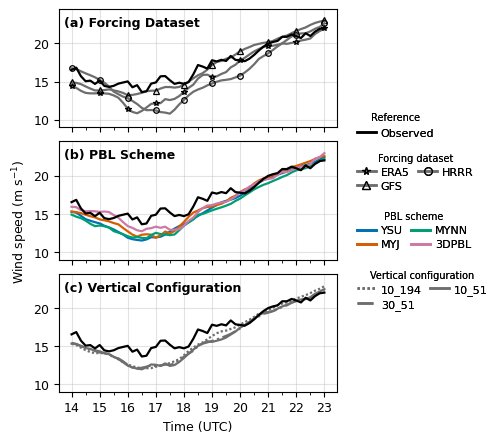

Saved: timeseries_ws_means/E05/ws_timeseries_3panel_mean_E05_140m.pdf
Saved: timeseries_ws_means/E05/ws_timeseries_3panel_mean_E05_140m.png


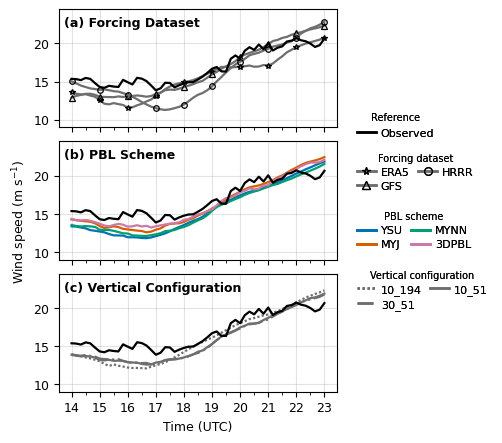

Saved: timeseries_ws_means/E06/ws_timeseries_3panel_mean_E06_140m.pdf
Saved: timeseries_ws_means/E06/ws_timeseries_3panel_mean_E06_140m.png
Done. Outputs in: timeseries_ws_means/E05 and timeseries_ws_means/E06


In [42]:
# ====================== Time series @ selected HEIGHT — 3 panels ======================
# Panel 1: forcing-dataset mean
# Panel 2: PBL-scheme mean
# Panel 3: vertical-configuration mean
#
# Encoding:
# - forcing panel: grey lines + ICBC markers
# - PBL panel: PBL colors
# - vertical panel: grey lines + vertical-configuration linestyles
# - lidar observations: black
#
# Layout:
# - compact figure (~75% manuscript text width at natural PDF size)
# - plotting panels on left
# - legends stacked vertically on right
# - two columns within each multi-option legend

import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from datetime import datetime, timedelta


# ============================================================
# USER SETTINGS
# ============================================================

# Target height: must be one of 20, 40, ..., 200 m
HEIGHT_M = 140

# Marker spacing in forcing panel
# 6 = every hour for 10-min data
# 3 = every 30 min
FORCING_MARKER_EVERY = 6


# ============================================================
# JOURNAL STYLING
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.titlesize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# LAYOUT / EXPORT
# ============================================================

# ~75% of a ~6.85-in manuscript text width
# Natural PDF size should therefore work in Overleaf without width=...
FIGSIZE_3PAN = (5.15, 4.5)

DPI_PNG = 300


# ============================================================
# DATA ROOTS
# ============================================================

BASE_DIR_3DPBL = (
    "/glade/work/mhafsah/Analysis_Proj_1/WS_all_runs"
)

BASE_DIR_MAIN = (
    "/glade/work/mhafsah/Analysis_Proj_1/WS_d02"
)

OUT_ROOT = "timeseries_ws_means"

LOCATIONS = ["E05", "E06"]
ICBCS = ["era5", "gfs", "hrrr"]
PBLS = ["ysu", "myj", "mynn", "3dpbl"]
VERTS = ["54", "80", "93"]


# ============================================================
# COLORS / LINESTYLES / MARKERS
# ============================================================

# PBL colors
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# Vertical configurations
vert_to_label = {
    "54": "10_194",
    "80": "30_51",
    "93": "10_51",
}

vert_to_ls = {
    "54": (0, (1, 1)),  # dotted
    "80": "-.",         # dash-dot
    "93": "-",          # solid
}

vert_legend_color = "#6E6E6E"

# Forcing markers
icbc_marker = {
    "era5": "*",
    "gfs": "^",
    "hrrr": "o",
}


# ============================================================
# VALIDATE HEIGHT
# ============================================================

if HEIGHT_M % 20 != 0 or not (20 <= HEIGHT_M <= 200):
    raise ValueError(
        f"HEIGHT_M must be in {{20,40,...,200}}; got {HEIGHT_M}"
    )

H_IDX = HEIGHT_M // 20 - 1


# ============================================================
# TIME AXIS
# ============================================================

START_TIME = datetime(2020, 5, 15, 14, 0, 0)
STEP_MIN = 10


# ============================================================
# FILE NAMING
# ============================================================

run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_'
    r'(?P<pbl>ysu|myj|mynn|3dpbl)_'
    r'vert(?P<vert>54|80|93)$'
)


# ============================================================
# HELPERS
# ============================================================

def index_files():
    """
    Recursive indexing.

    WS_all_runs:
        only 3DPBL runs

    WS_d02:
        all non-3DPBL runs
    """

    out = []

    def scan_root(
        root,
        allow_pbl=None,
        skip_pbl=None
    ):
        for loc in LOCATIONS:

            pattern = os.path.join(
                root,
                "**",
                f"WS_{loc}.npy"
            )

            for f in glob.glob(
                pattern,
                recursive=True
            ):

                run_dir = os.path.basename(
                    os.path.dirname(f)
                )

                match = run_dir_pat.match(run_dir)

                if not match:
                    continue

                group = match.groupdict()

                icbc = group["icbc"]
                pbl = group["pbl"]
                vert = group["vert"]

                if (
                    allow_pbl is not None
                    and pbl not in allow_pbl
                ):
                    continue

                if (
                    skip_pbl is not None
                    and pbl in skip_pbl
                ):
                    continue

                out.append(
                    (
                        f,
                        icbc,
                        pbl,
                        vert,
                        loc
                    )
                )

    scan_root(
        BASE_DIR_3DPBL,
        allow_pbl={"3dpbl"}
    )

    scan_root(
        BASE_DIR_MAIN,
        skip_pbl={"3dpbl"}
    )

    return out


def load_ts_height(path):
    """
    Return time series at HEIGHT_M.

    Accepts:
      (time, 10)
      (time,)
    """

    arr = np.load(path)

    if arr.ndim == 2:
        return arr[:, H_IDX]

    if arr.ndim == 1:
        return arr

    raise ValueError(
        f"Unexpected array shape {arr.shape} in {path}"
    )


def find_obs_ws(loc):
    """
    Load WS_<loc>_OBS.npy.

    Search:
      1. current directory
      2. model roots
      3. recursively under model roots
    """

    filename = f"WS_{loc}_OBS.npy"

    here = os.path.join(
        os.getcwd(),
        filename
    )

    if os.path.exists(here):
        return load_ts_height(here)

    for root in (
        BASE_DIR_3DPBL,
        BASE_DIR_MAIN
    ):

        candidate = os.path.join(
            root,
            filename
        )

        if os.path.exists(candidate):
            return load_ts_height(candidate)

        hits = glob.glob(
            os.path.join(
                root,
                "**",
                filename
            ),
            recursive=True
        )

        if hits:
            return load_ts_height(
                hits[0]
            )

    print(
        f"[{loc}] WS observation file "
        f"not found ({filename})."
    )

    return None


def make_time_index(
    n,
    start_dt=START_TIME,
    step_min=STEP_MIN
):
    return [
        start_dt
        + timedelta(
            minutes=i * step_min
        )
        for i in range(n)
    ]


def ensure_outdir(loc):

    outdir = os.path.join(
        OUT_ROOT,
        loc
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    return outdir


def style_time_axis(ax):

    ax.grid(
        True,
        alpha=0.35,
        linewidth=0.8
    )

    ax.xaxis.set_major_locator(
        mdates.HourLocator(
            interval=1
        )
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%H")
    )

    ax.xaxis.set_minor_locator(
        mdates.MinuteLocator(
            byminute=[0, 30]
        )
    )


def get_marker_indices(
    n,
    step=6
):
    return list(
        range(
            0,
            n,
            step
        )
    )


def compute_heightwise_ylims(
    idx,
    pad=0.5
):
    """
    One common y-axis range for:
      - both buoys
      - all configurations
      - observations
    at the selected height.
    """

    vals = []

    # Model series
    for (
        f,
        icbc,
        pbl,
        vert,
        loc
    ) in idx:

        try:
            y = load_ts_height(f)

            vals.extend(
                np.asarray(y).ravel()
            )

        except Exception:
            continue

    # Observations
    for loc in LOCATIONS:

        ws_obs = find_obs_ws(loc)

        if ws_obs is not None:

            vals.extend(
                np.asarray(
                    ws_obs
                ).ravel()
            )

    vals = np.asarray(
        vals,
        dtype=float
    )

    vals = vals[
        np.isfinite(vals)
    ]

    if vals.size == 0:

        raise ValueError(
            "No valid wind-speed values "
            "found to compute y-limits."
        )

    ymin = (
        np.floor(
            (vals.min() - pad) * 2
        ) / 2
    )

    ymax = (
        np.ceil(
            (vals.max() + pad) * 2
        ) / 2
    )

    return (
        ymin,
        ymax
    )


def mean_of_series(
    series_list
):
    """
    Mean across a list of 1D arrays.
    """

    if len(series_list) == 0:
        return None

    min_len = min(
        len(s)
        for s in series_list
    )

    arr = np.array(
        [
            np.asarray(
                s[:min_len],
                dtype=float
            )
            for s in series_list
        ],
        dtype=float
    )

    return np.nanmean(
        arr,
        axis=0
    )


# ============================================================
# GROUPING HELPERS
# ============================================================

def get_series_for_icbc(
    idx,
    loc,
    icbc_target
):

    out = []

    for (
        f,
        icbc,
        pbl,
        vert,
        L
    ) in idx:

        if (
            L == loc
            and icbc == icbc_target
        ):

            out.append(
                load_ts_height(f)
            )

    return out


def get_series_for_pbl(
    idx,
    loc,
    pbl_target
):

    out = []

    for (
        f,
        icbc,
        pbl,
        vert,
        L
    ) in idx:

        if (
            L == loc
            and pbl == pbl_target
        ):

            out.append(
                load_ts_height(f)
            )

    return out


def get_series_for_vert(
    idx,
    loc,
    vert_target
):

    out = []

    for (
        f,
        icbc,
        pbl,
        vert,
        L
    ) in idx:

        if (
            L == loc
            and vert == vert_target
        ):

            out.append(
                load_ts_height(f)
            )

    return out


# ============================================================
# LEGENDS — STACKED ON RIGHT
# ============================================================

def add_right_legends(fig):
    """
    Legend groups are stacked vertically on the right.

    Forcing dataset:
        3 options, ncol=2

    PBL scheme:
        4 options, ncol=2

    Vertical configuration:
        3 options, ncol=2

    Reference:
        one option
    """

    title_fs = 7
    label_fs = 8

    # --------------------------------------------------------
    # Forcing dataset
    # --------------------------------------------------------

    forcing_handles = [
        Line2D(
            [0], [0],
            color=vert_legend_color,
            lw=1.8,
            linestyle="-",
            marker=icbc_marker[i],
            markersize=5.5,
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=0.9,
            label=i.upper()
        )
        for i in [
            "era5",
            "gfs",
            "hrrr"
        ]
    ]

    # --------------------------------------------------------
    # PBL scheme
    # --------------------------------------------------------

    pbl_handles = [
        Line2D(
            [0], [0],
            color=pbl_color[p],
            lw=2.0,
            linestyle="-",
            label=(
                "3DPBL"
                if p == "3dpbl"
                else p.upper()
            )
        )
        for p in [
            "ysu",
            "myj",
            "mynn",
            "3dpbl"
        ]
    ]

    # --------------------------------------------------------
    # Vertical configuration
    # --------------------------------------------------------

    vert_handles = [
        Line2D(
            [0], [0],
            color=vert_legend_color,
            lw=1.8,
            linestyle=vert_to_ls[v],
            label=vert_to_label[v]
        )
        for v in [
            "54",
            "80",
            "93"
        ]
    ]

    # --------------------------------------------------------
    # Observation
    # --------------------------------------------------------

    ref_handles = [
        Line2D(
            [0], [0],
            color="black",
            lw=1.8,
            linestyle="-",
            label="Observed"
        )
    ]
    # --------------------------------------------------------
    # Legend 1 — Reference
    # --------------------------------------------------------
    
    leg1 = fig.legend(
        handles=ref_handles,
        loc="upper left",
        bbox_to_anchor=(0.70, 0.75),
        frameon=False,
        ncol=1,
        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=1.7,
        handletextpad=0.45,
        borderaxespad=0.0,
    )
    
    # --------------------------------------------------------
    # Legend 2 — Forcing dataset
    # --------------------------------------------------------
    
    leg2 = fig.legend(
        handles=forcing_handles,
        loc="upper left",
        bbox_to_anchor=(0.70, 0.66),
        frameon=False,
        ncol=2,
        title="Forcing dataset",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=1.7,
        handletextpad=0.45,
        columnspacing=0.75,
        labelspacing=0.35,
        borderaxespad=0.0,
    )
    
    # --------------------------------------------------------
    # Legend 3 — PBL scheme
    # --------------------------------------------------------
    
    leg3 = fig.legend(
        handles=pbl_handles,
        loc="upper left",
        bbox_to_anchor=(0.70, 0.53),
        frameon=False,
        ncol=2,
        title="PBL scheme",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=1.7,
        handletextpad=0.45,
        columnspacing=0.75,
        labelspacing=0.35,
        borderaxespad=0.0,
    )
    
    # --------------------------------------------------------
    # Legend 4 — Vertical configuration
    # --------------------------------------------------------
    
    leg4 = fig.legend(
        handles=vert_handles,
        loc="upper left",
        bbox_to_anchor=(0.70, 0.40),
        frameon=False,
        ncol=2,
        title="Vertical configuration",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=1.7,
        handletextpad=0.45,
        columnspacing=0.70,
        labelspacing=0.35,
        borderaxespad=0.0,
    )
    
    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)
    fig.add_artist(leg4)


# ============================================================
# PANEL 1 — FORCING DATASET
# ============================================================

def plot_panel_forcing(
    ax,
    loc,
    idx,
    ws_obs,
    t_ref,
    ylims,
    panel_txt
):

    for icbc in ICBCS:

        series = get_series_for_icbc(
            idx,
            loc,
            icbc
        )

        y = mean_of_series(
            series
        )

        if y is None:
            continue

        n = len(y)

        mark_idxs = get_marker_indices(
            n,
            step=FORCING_MARKER_EVERY
        )

        ax.plot(
            t_ref[:n],
            y,

            color=vert_legend_color,
            linestyle="-",
            linewidth=1.6,

            marker=icbc_marker[icbc],
            markevery=mark_idxs,
            markersize=4,

            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=0.9,
        )

    if ws_obs is not None:

        ax.plot(
            t_ref[:len(ws_obs)],
            ws_obs,

            color="black",
            linestyle="-",
            linewidth=1.6,
            zorder=5
        )

    ax.set_ylim(
        ylims
    )

    style_time_axis(
        ax
    )

    ax.text(
        0.02,
        0.94,

        f"{panel_txt} Forcing Dataset",

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# PANEL 2 — PBL SCHEME
# ============================================================

def plot_panel_pbl(
    ax,
    loc,
    idx,
    ws_obs,
    t_ref,
    ylims,
    panel_txt
):

    for pbl in PBLS:

        series = get_series_for_pbl(
            idx,
            loc,
            pbl
        )

        y = mean_of_series(
            series
        )

        if y is None:
            continue

        ax.plot(
            t_ref[:len(y)],
            y,

            color=pbl_color[pbl],
            linestyle="-",
            linewidth=1.6
        )

    if ws_obs is not None:

        ax.plot(
            t_ref[:len(ws_obs)],
            ws_obs,

            color="black",
            linestyle="-",
            linewidth=1.6,
            zorder=5
        )

    ax.set_ylim(
        ylims
    )

    style_time_axis(
        ax
    )

    ax.text(
        0.02,
        0.94,

        f"{panel_txt} PBL Scheme",

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# PANEL 3 — VERTICAL CONFIGURATION
# ============================================================

def plot_panel_vert(
    ax,
    loc,
    idx,
    ws_obs,
    t_ref,
    ylims,
    panel_txt
):

    for vert in VERTS:

        series = get_series_for_vert(
            idx,
            loc,
            vert
        )

        y = mean_of_series(
            series
        )

        if y is None:
            continue

        ax.plot(
            t_ref[:len(y)],
            y,

            color=vert_legend_color,
            linestyle=vert_to_ls[vert],
            linewidth=1.6
        )

    if ws_obs is not None:

        ax.plot(
            t_ref[:len(ws_obs)],
            ws_obs,

            color="black",
            linestyle="-",
            linewidth=1.6,
            zorder=5
        )

    ax.set_ylim(
        ylims
    )

    style_time_axis(
        ax
    )

    ax.text(
        0.02,
        0.94,

        f"{panel_txt} Vertical Configuration",

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# 3-PANEL FIGURE PER BUOY
# ============================================================

def plot_ws_3panel_per_buoy(
    loc,
    idx,
    ylims
):

    outdir = ensure_outdir(
        loc
    )

    ws_obs = find_obs_ws(
        loc
    )

    # Determine longest available time series
    max_n = 0

    for (
        f,
        icbc,
        pbl,
        vert,
        L
    ) in idx:

        if L != loc:
            continue

        try:

            y = load_ts_height(f)

            max_n = max(
                max_n,
                len(y)
            )

        except Exception:
            continue

    if ws_obs is not None:

        max_n = max(
            max_n,
            len(ws_obs)
        )

    if max_n == 0:

        print(
            f"[{loc}] No time series found."
        )

        return

    t_ref = make_time_index(
        max_n
    )

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axs = plt.subplots(
        3,
        1,

        figsize=FIGSIZE_3PAN,

        sharex=True,
        sharey=True
    )

    # Main change:
    # right side reserved for stacked legends
    fig.subplots_adjust(
        left=0.13,
        right=0.67,
        top=0.97,
        bottom=0.12,
        hspace=0.12
    )

    # Shared y-axis label
    fig.supylabel(
        "Wind speed (m s$^{-1}$)",
        fontsize=9,
        x=0.035
    )

    # --------------------------------------------------------
    # Panels
    # --------------------------------------------------------

    plot_panel_forcing(
        axs[0],
        loc,
        idx,
        ws_obs,
        t_ref,
        ylims,
        "(a)"
    )

    plot_panel_pbl(
        axs[1],
        loc,
        idx,
        ws_obs,
        t_ref,
        ylims,
        "(b)"
    )

    plot_panel_vert(
        axs[2],
        loc,
        idx,
        ws_obs,
        t_ref,
        ylims,
        "(c)"
    )

    axs[2].set_xlabel(
        "Time (UTC)"
    )

    # --------------------------------------------------------
    # Legends on right
    # --------------------------------------------------------

    add_right_legends(
        fig
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    base = (
        f"ws_timeseries_3panel_mean_"
        f"{loc}_{HEIGHT_M}m"
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    print(
        f"Saved: {pdf_path}"
    )

    print(
        f"Saved: {png_path}"
    )


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    idx = index_files()

    os.makedirs(
        OUT_ROOT,
        exist_ok=True
    )

    ylims = compute_heightwise_ylims(
        idx,
        pad=0.5
    )

    print(
        f"Using y-limits for "
        f"{HEIGHT_M} m: {ylims}"
    )

    for loc in LOCATIONS:

        plot_ws_3panel_per_buoy(
            loc,
            idx,
            ylims
        )

    print(
        f"Done. Outputs in: "
        f"{OUT_ROOT}/E05 and "
        f"{OUT_ROOT}/E06"
    )

Using target time: 2020-05-15 15:20:00 UTC
Target index relative to 14:00 UTC = 8
Using fixed x-limits: (6.5, 17.0)


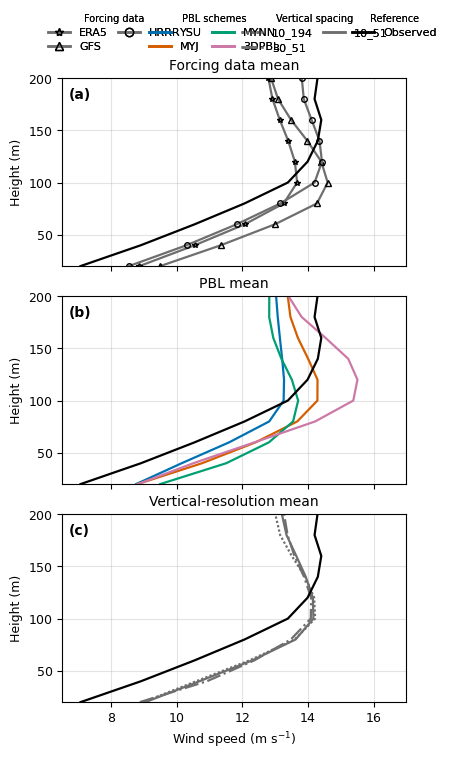

Saved: vertical_profiles_selected_time/E05/ws_vertical_3panel_mean_E05_1520UTC.[pdf/png]


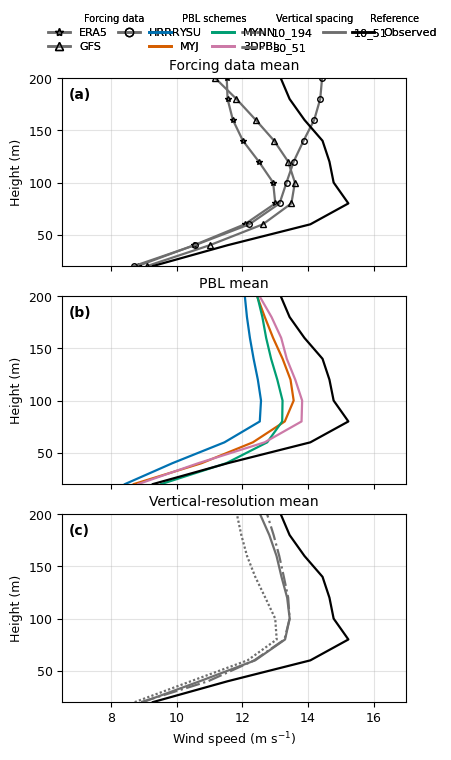

Saved: vertical_profiles_selected_time/E06/ws_vertical_3panel_mean_E06_1520UTC.[pdf/png]
Done. Outputs in: vertical_profiles_selected_time/E05 and vertical_profiles_selected_time/E06


In [2]:
# ====================== Vertical profiles @ chosen UTC time — 3 panels ======================
# Panel 1: ICBC mean profile
# Panel 2: PBL mean profile
# Panel 3: vertical-resolution mean profile
#
# For each run:
#   - load WS(time, height)
#   - extract profile at TARGET_TIME_STR
# Then average profiles within each category.
#
# Observation:
#   - WS_<loc>_OBS.npy at TARGET_TIME_STR
#
# Change only:
#   TARGET_TIME_STR = "15:10"   # any valid time like "14:00", "16:30", "22:50"
#
# Output:
#   vertical_profiles_selected_time/E05/*.pdf, *.png
#   vertical_profiles_selected_time/E06/*.pdf, *.png

import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from datetime import datetime

# ===================== USER SETTINGS =====================
TARGET_TIME_STR = "15:20"   # <-- CHANGE THIS ONLY (format HH:MM)

START_TIME = datetime(2020, 5, 15, 14, 0, 0)
STEP_MIN   = 10

BASE_DIR_3DPBL = "/glade/work/mhafsah/Analysis_Proj_1/WS_all_runs"   # only 3dpbl runs
BASE_DIR_MAIN  = "/glade/work/mhafsah/Analysis_Proj_1/WS_d02"        # everything else

OUT_ROOT = "vertical_profiles_selected_time"

LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]
VERTS     = ["54", "80", "93"]

z = np.array([20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

# ===================== Plot style =====================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.titlesize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGSIZE_3PAN = (4, 7.8)
DPI_PNG = 300

# ===================== Style maps =====================
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

vert_to_label = {"54": "10_194", "80": "30_51", "93": "10_51"}
vert_to_ls    = {"54": (0, (1, 1)), "80": "-.", "93": "-"}
vert_legend_color = "#6E6E6E"

icbc_marker = {"era5": "*", "gfs": "^", "hrrr": "o"}

# ===================== File naming =====================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

# ===================== Time helper =====================
def parse_target_time(time_str, base_date=START_TIME):
    """
    Convert 'HH:MM' to a datetime on the same date as START_TIME.
    """
    hh, mm = map(int, time_str.split(":"))
    return datetime(base_date.year, base_date.month, base_date.day, hh, mm, 0)

def target_time_index(start_dt=START_TIME, target_time_str=TARGET_TIME_STR, step_min=STEP_MIN):
    """
    Compute time index from a target UTC time string like '15:10'.
    """
    target_dt = parse_target_time(target_time_str, start_dt)
    delta_min = int((target_dt - start_dt).total_seconds() // 60)

    if delta_min < 0:
        raise ValueError(f"TARGET_TIME_STR={target_time_str} is before START_TIME={start_dt.strftime('%H:%M')}")

    if delta_min % step_min != 0:
        raise ValueError(
            f"TARGET_TIME_STR={target_time_str} is not aligned with {step_min}-minute data."
        )

    return delta_min // step_min, target_dt

TARGET_IDX, TARGET_DT = target_time_index()

# ===================== Helpers =====================
def index_files():
    """
    Recursive indexing:
      - search for WS_E05.npy / WS_E06.npy anywhere under each root
      - infer (icbc, pbl, vert) from parent directory name like gfs_3dpbl_vert80
      - enforce:
            WS_all_runs -> only 3dpbl
            WS_d02      -> everything except 3dpbl
    """
    out = []

    def scan_root(root, allow_pbl=None, skip_pbl=None):
        for loc in LOCATIONS:
            for f in glob.glob(os.path.join(root, "**", f"WS_{loc}.npy"), recursive=True):
                run_dir = os.path.basename(os.path.dirname(f))
                m = run_dir_pat.match(run_dir)
                if not m:
                    continue

                g = m.groupdict()
                icbc, pbl, vert = g["icbc"], g["pbl"], g["vert"]

                if allow_pbl is not None and pbl not in allow_pbl:
                    continue
                if skip_pbl is not None and pbl in skip_pbl:
                    continue

                out.append((f, icbc, pbl, vert, loc))

    scan_root(BASE_DIR_3DPBL, allow_pbl={"3dpbl"})
    scan_root(BASE_DIR_MAIN, skip_pbl={"3dpbl"})
    return out

def load_ws_2d(path):
    arr = np.load(path)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array (time,height), got {arr.shape} in {path}")
    return arr

def extract_profile_at_time(path, tidx=TARGET_IDX):
    arr = load_ws_2d(path)
    if tidx >= arr.shape[0]:
        raise ValueError(f"Time index {tidx} out of bounds for {path} with shape {arr.shape}")
    return np.asarray(arr[tidx, :], dtype=float)

def find_obs_ws(loc):
    """
    Load WS_<loc>_OBS.npy and return full 2D array.
    Search:
      1) current working directory
      2) either root (direct + recursive)
    """
    filename = f"WS_{loc}_OBS.npy"

    here = os.path.join(os.getcwd(), filename)
    if os.path.exists(here):
        return load_ws_2d(here)

    for root in (BASE_DIR_3DPBL, BASE_DIR_MAIN):
        cand = os.path.join(root, filename)
        if os.path.exists(cand):
            return load_ws_2d(cand)

        hits = glob.glob(os.path.join(root, "**", filename), recursive=True)
        if hits:
            return load_ws_2d(hits[0])

    print(f"[{loc}] WS observation file not found ({filename}).")
    return None

def obs_profile_at_time(loc, tidx=TARGET_IDX):
    arr = find_obs_ws(loc)
    if arr is None:
        return None
    if tidx >= arr.shape[0]:
        print(f"[{loc}] Observation array too short for time index {tidx}.")
        return None
    return np.asarray(arr[tidx, :], dtype=float)

def mean_of_profiles(profile_list):
    """
    Mean across a list of 1D profiles of equal height dimension.
    Returns (height,) array.
    """
    if len(profile_list) == 0:
        return None
    arr = np.array([np.asarray(p, dtype=float) for p in profile_list], dtype=float)
    return np.nanmean(arr, axis=0)

def ensure_outdir(loc):
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir

def panel_label(ax, txt):
    ax.text(
        0.02, 0.95, txt,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10, fontweight="bold"
    )

def compute_fixed_xlim(idx, pad=0.3):
    """
    One fixed x-limit across both locations and all three panels,
    based on all model + observation profiles at TARGET_TIME_STR.
    """
    vals = []

    for f, icbc, pbl, vert, loc in idx:
        try:
            prof = extract_profile_at_time(f, TARGET_IDX)
            vals.extend(prof.ravel())
        except Exception:
            continue

    for loc in LOCATIONS:
        try:
            prof_obs = obs_profile_at_time(loc, TARGET_IDX)
            if prof_obs is not None:
                vals.extend(prof_obs.ravel())
        except Exception:
            continue

    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        raise ValueError("No valid values found to compute x-limits.")

    xmin = np.floor((vals.min() - pad) * 2) / 2
    xmax = np.ceil((vals.max() + pad) * 2) / 2
    return (xmin, xmax)

# ===================== Grouping helpers =====================
def get_profiles_for_icbc(idx, loc, icbc_target):
    out = []
    for f, icbc, pbl, vert, L in idx:
        if L == loc and icbc == icbc_target:
            out.append(extract_profile_at_time(f, TARGET_IDX))
    return out

def get_profiles_for_pbl(idx, loc, pbl_target):
    out = []
    for f, icbc, pbl, vert, L in idx:
        if L == loc and pbl == pbl_target:
            out.append(extract_profile_at_time(f, TARGET_IDX))
    return out

def get_profiles_for_vert(idx, loc, vert_target):
    out = []
    for f, icbc, pbl, vert, L in idx:
        if L == loc and vert == vert_target:
            out.append(extract_profile_at_time(f, TARGET_IDX))
    return out

# ===================== Legends =====================
def add_grouped_top_legends(fig):
    title_fs = 7
    label_fs = 8

    forcing_handles = [
        Line2D([0], [0],
               color=vert_legend_color,
               lw=1.8,
               linestyle="-",
               marker=icbc_marker[i],
               markersize=6,
               markerfacecolor="none",
               markeredgecolor="black",
               markeredgewidth=1.0,
               label=i.upper())
        for i in ["era5", "gfs", "hrrr"]
    ]

    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    vert_handles = [
        Line2D([0], [0],
               color=vert_legend_color,
               lw=1.8,
               linestyle=vert_to_ls[v],
               label=vert_to_label[v])
        for v in ["54", "80", "93"]
    ]

    ref_handles = [
        Line2D([0], [0], color="black", lw=1.8, linestyle="-", label="Observed")
    ]

    leg1 = fig.legend(
        handles=forcing_handles,
        loc="upper center",
        bbox_to_anchor=(0.25, 0.995),
        frameon=False,
        ncol=2,
        title="Forcing data",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35
    )

    leg2 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.50, 0.995),
        frameon=False,
        ncol=2,
        title="PBL schemes",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35
    )

    leg3 = fig.legend(
        handles=vert_handles,
        loc="upper center",
        bbox_to_anchor=(0.75, 0.995),
        frameon=False,
        ncol=2,
        title="Vertical spacing",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35
    )

    leg4 = fig.legend(
        handles=ref_handles,
        loc="upper center",
        bbox_to_anchor=(0.95, 0.995),
        frameon=False,
        ncol=1,
        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)
    fig.add_artist(leg4)

# ===================== Panel plotters =====================
def plot_panel_icbc(ax, loc, idx, obs_prof, xlims, panel_txt):
    for icbc in ICBCS:
        profiles = get_profiles_for_icbc(idx, loc, icbc)
        prof = mean_of_profiles(profiles)
        if prof is None:
            continue

        ax.plot(
            prof, z,
            color=vert_legend_color,
            linestyle="-",
            linewidth=1.6,
            marker=icbc_marker[icbc],
            markersize=4,
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=1.0,
        )

    if obs_prof is not None:
        ax.plot(obs_prof, z, color="black", linestyle="-", linewidth=1.6, zorder=5)

    ax.set_title("Forcing data mean")
    ax.set_xlim(xlims)
    ax.set_ylim(20, 200)
    ax.grid(True, alpha=0.35, linewidth=0.8)
    panel_label(ax, panel_txt)

def plot_panel_pbl(ax, loc, idx, obs_prof, xlims, panel_txt):
    for pbl in PBLS:
        profiles = get_profiles_for_pbl(idx, loc, pbl)
        prof = mean_of_profiles(profiles)
        if prof is None:
            continue

        ax.plot(
            prof, z,
            color=pbl_color[pbl],
            linestyle="-",
            linewidth=1.6
        )

    if obs_prof is not None:
        ax.plot(obs_prof, z, color="black", linestyle="-", linewidth=1.6, zorder=5)

    ax.set_title("PBL mean")
    ax.set_xlim(xlims)
    ax.set_ylim(20, 200)
    ax.grid(True, alpha=0.35, linewidth=0.8)
    panel_label(ax, panel_txt)

def plot_panel_vert(ax, loc, idx, obs_prof, xlims, panel_txt):
    for vert in VERTS:
        profiles = get_profiles_for_vert(idx, loc, vert)
        prof = mean_of_profiles(profiles)
        if prof is None:
            continue

        ax.plot(
            prof, z,
            color=vert_legend_color,
            linestyle=vert_to_ls[vert],
            linewidth=1.6
        )

    if obs_prof is not None:
        ax.plot(obs_prof, z, color="black", linestyle="-", linewidth=1.6, zorder=5)

    ax.set_title("Vertical-resolution mean")
    ax.set_xlim(xlims)
    ax.set_ylim(20, 200)
    ax.grid(True, alpha=0.35, linewidth=0.8)
    panel_label(ax, panel_txt)

# ===================== Main figure per buoy =====================
def plot_vertical_3panel_per_buoy(loc, idx, xlims):
    outdir = ensure_outdir(loc)
    obs_prof = obs_profile_at_time(loc, TARGET_IDX)

    fig, axs = plt.subplots(3, 1, figsize=FIGSIZE_3PAN, sharex=True, sharey=True)
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        top=0.90,
        bottom=0.10,
        hspace=0.16
    )

    plot_panel_icbc(axs[0], loc, idx, obs_prof, xlims, "(a)")
    plot_panel_pbl (axs[1], loc, idx, obs_prof, xlims, "(b)")
    plot_panel_vert(axs[2], loc, idx, obs_prof, xlims, "(c)")

    axs[0].set_ylabel("Height (m)")
    axs[1].set_ylabel("Height (m)")
    axs[2].set_ylabel("Height (m)")
    axs[2].set_xlabel("Wind speed (m s$^{-1}$)")

    add_grouped_top_legends(fig)

    time_tag = TARGET_DT.strftime("%H%MUTC")
    base = f"ws_vertical_3panel_mean_{loc}_{time_tag}"
    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    print(f"Using target time: {TARGET_DT.strftime('%Y-%m-%d %H:%M:%S UTC')}")
    print(f"Target index relative to {START_TIME.strftime('%H:%M UTC')} = {TARGET_IDX}")

    idx = index_files()
    os.makedirs(OUT_ROOT, exist_ok=True)

    xlims = compute_fixed_xlim(idx, pad=0.3)
    print(f"Using fixed x-limits: {xlims}")

    for loc in LOCATIONS:
        plot_vertical_3panel_per_buoy(loc, idx, xlims)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Using target time: 2020-05-15 15:20:00 UTC
Target index relative to 14:00 UTC = 8
Using fixed x-limits: (6.5, 17.0)


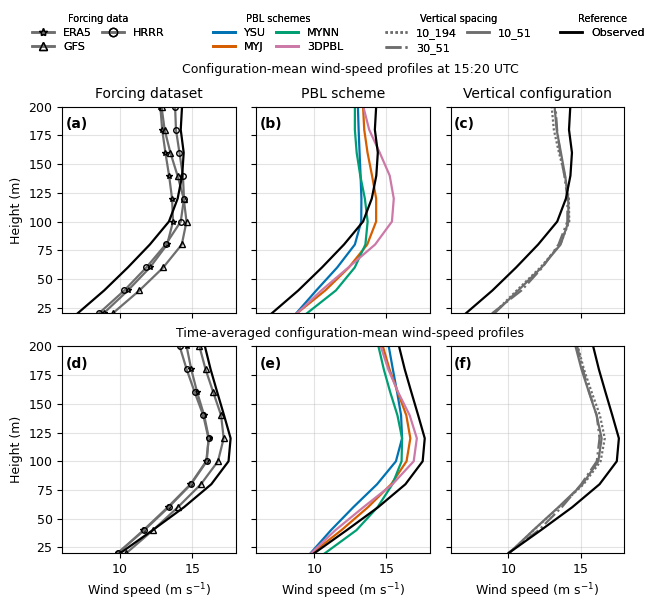

Saved: vertical_profiles_selected_time/E05/ws_vertical_3x2_E05_1520UTC_and_mean.[pdf/png]


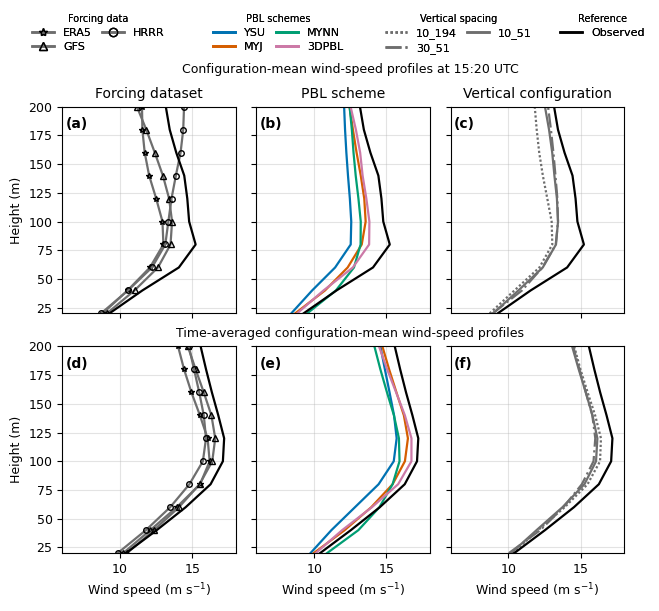

Saved: vertical_profiles_selected_time/E06/ws_vertical_3x2_E06_1520UTC_and_mean.[pdf/png]
Done. Outputs in: vertical_profiles_selected_time/E05 and vertical_profiles_selected_time/E06


In [3]:
FIGSIZE_3X2 = (7.2, 6.2)

def mean_profile_over_time(path):
    arr = load_ws_2d(path)
    return np.nanmean(arr, axis=0)

def obs_mean_profile(loc):
    arr = find_obs_ws(loc)
    if arr is None:
        return None
    return np.nanmean(arr, axis=0)

def get_profiles_for_icbc_mean(idx, loc, icbc_target):
    return [mean_profile_over_time(f) for f, icbc, pbl, vert, L in idx
            if L == loc and icbc == icbc_target]

def get_profiles_for_pbl_mean(idx, loc, pbl_target):
    return [mean_profile_over_time(f) for f, icbc, pbl, vert, L in idx
            if L == loc and pbl == pbl_target]

def get_profiles_for_vert_mean(idx, loc, vert_target):
    return [mean_profile_over_time(f) for f, icbc, pbl, vert, L in idx
            if L == loc and vert == vert_target]


def plot_vertical_3x2_per_buoy(loc, idx, xlims):
    outdir = ensure_outdir(loc)

    obs_inst = obs_profile_at_time(loc, TARGET_IDX)
    obs_mean = obs_mean_profile(loc)

    fig, axs = plt.subplots(
        2, 3,
        figsize=FIGSIZE_3X2,
        sharex=True,
        sharey=True,
        constrained_layout=False
    )

    fig.subplots_adjust(
        left=0.20,
        right=0.98,
        top=0.83,
        bottom=0.11,
        wspace=0.12,
        hspace=0.16
    )

    # ---------- Top row: 15:20 UTC ----------
    plot_panel_icbc(axs[0, 0], loc, idx, obs_inst, xlims, "(a)")
    plot_panel_pbl (axs[0, 1], loc, idx, obs_inst, xlims, "(b)")
    plot_panel_vert(axs[0, 2], loc, idx, obs_inst, xlims, "(c)")

    # ---------- Bottom row: time mean ----------
    for icbc in ICBCS:
        prof = mean_of_profiles(get_profiles_for_icbc_mean(idx, loc, icbc))
        if prof is not None:
            axs[1, 0].plot(
                prof, z,
                color=vert_legend_color,
                linestyle="-",
                linewidth=1.6,
                marker=icbc_marker[icbc],
                markersize=4,
                markerfacecolor="none",
                markeredgecolor="black",
                markeredgewidth=1.0
            )

    for pbl in PBLS:
        prof = mean_of_profiles(get_profiles_for_pbl_mean(idx, loc, pbl))
        if prof is not None:
            axs[1, 1].plot(
                prof, z,
                color=pbl_color[pbl],
                linestyle="-",
                linewidth=1.6
            )

    for vert in VERTS:
        prof = mean_of_profiles(get_profiles_for_vert_mean(idx, loc, vert))
        if prof is not None:
            axs[1, 2].plot(
                prof, z,
                color=vert_legend_color,
                linestyle=vert_to_ls[vert],
                linewidth=1.6
            )

    for ax in axs[1, :]:
        if obs_mean is not None:
            ax.plot(obs_mean, z, color="black", linestyle="-", linewidth=1.6, zorder=5)
        ax.set_xlim(6, 18)
        ax.set_ylim(20, 200)
        ax.grid(True, alpha=0.35, linewidth=0.8)

    panel_label(axs[1, 0], "(d)")
    panel_label(axs[1, 1], "(e)")
    panel_label(axs[1, 2], "(f)")

    # Copernicus-style concise column titles
    axs[0, 0].set_title("Forcing dataset")
    axs[0, 1].set_title("PBL scheme")
    axs[0, 2].set_title("Vertical configuration")

    for ax in axs[1, :]:
        ax.set_title("")

    axs[0, 0].set_ylabel("Height (m)")
    axs[1, 0].set_ylabel("Height (m)")

    for ax in axs[1, :]:
        ax.set_xlabel("Wind speed (m s$^{-1}$)")

    # Row labels
    fig.text(0.6, 0.90, "Configuration-mean wind-speed profiles at 15:20 UTC", ha="center", va="top", fontsize=9)
    fig.text(0.6, 0.475, "Time-averaged configuration-mean wind-speed profiles", ha="center", va="top", fontsize=9)
    add_grouped_top_legends(fig)

    time_tag = TARGET_DT.strftime("%H%MUTC")
    base = f"ws_vertical_3x2_{loc}_{time_tag}_and_mean"

    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")

# ===================== RUN =====================
if __name__ == "__main__":
    print(f"Using target time: {TARGET_DT.strftime('%Y-%m-%d %H:%M:%S UTC')}")
    print(f"Target index relative to {START_TIME.strftime('%H:%M UTC')} = {TARGET_IDX}")

    idx = index_files()
    os.makedirs(OUT_ROOT, exist_ok=True)

    xlims = compute_fixed_xlim(idx, pad=0.3)
    print(f"Using fixed x-limits: {xlims}")

    for loc in LOCATIONS:
        plot_vertical_3x2_per_buoy(loc, idx, xlims)

    print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")